## 0. Import and Definitions

In [2]:
import json
import os
import copy
from sklearn.metrics import roc_curve, auc

import scanpy as sc
import anndata as ad
from mudata import MuData

import numpy as np
import matplotlib.pyplot as plt

from src.analysis.enrichment_shift import (
    analyze_shift_enrichment,
    analyze_holdout_enrichment,
    load_nets,
    EXPECTED_HALLMARK,
    EXPECTED_PROGENY,
)

from src.analysis.mmd import ctrl_mmd_dists, mmd_dists, plot_mmd_dists
from src.analysis.analysis_utils import (
    Analyzer,
)
from src.analysis.logistic_regression import (
    train_classifier,
    generate_counterfactuals,
    init_classifier,
    evaluate_training_error,
)
from src.analysis.cluster_analysis import (
    plot_latent_means_umap,
)

from src.model.data_utils import (
    load_data,
    get_condition_shapes,
    get_condition_vocab,
    split_holdout_combinations,
    prepare_train_test_data,
    load_metacells,
    create_latent_adata,
)
from src.model.training import train_model
from src.model.build_model import get_model, remap_keys, init_config
from src.model.naming import resolve_checkpoint, holdout_suffix
from src.model.config import INNConfig
from src.analysis.cf_expressions import (
    plot_mean_expression_comparison,
    plot_top_deg_violin,
    sample_from_means,
    plot_effect_size_comparison,
)
from src.analysis.pertubation_effects import (
    evaluate_de_effects,
)
from src.analysis.INN_OOD import (
    estimate_leftout_combo_mean,
    sample_leftout_combo_normal,
    sample_leftout_combo_shift,
    scoped_analyzer_for_combo,
    cfs_fn_from_adata,
    evaluate_leftout_combo_mmd,
    observed_combos_from_adata,
)

import warnings
import socket
import torch

from sklearn.decomposition import PCA

assert "login" not in socket.gethostname()

warnings.filterwarnings("ignore", category=FutureWarning)

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
adata = None
analyzer = None

## 1. Load Data

In [4]:
USE_METACELLS = True
DONOR = ["Donor1"]

# Which combos were held out of TRAINING. Point HOLDOUT_FILE at the same JSON the run
# used (train.py --holdout_file / train.sh HOLDOUT_FILE); ten combos give every OOD
# metric an error bar instead of one value on ~34 metacells. Set it to None to fall
# back to the single combo below, which is what older checkpoints were trained with.
HOLDOUT_FILE = "/home/jhoefer/sandbox/configs/holdout_combos.json"
HOLDOUT_COMBO = {"cytokine": "IL-2", "cell_type": "CD8 Memory"}  # used when HOLDOUT_FILE is None

if HOLDOUT_FILE is not None:
    with open(HOLDOUT_FILE) as handle:
        HOLDOUT_COMBOS = json.load(handle)
    # section 5 evaluates ONE combo at a time; take it from the set rather than
    # leaving the hardcoded value, so it is guaranteed to be one the model held out
    HOLDOUT_NAME, HOLDOUT_COMBO = next(iter(HOLDOUT_COMBOS.items()))
elif HOLDOUT_COMBO is not None:
    HOLDOUT_COMBOS, HOLDOUT_NAME = {"combo_1": HOLDOUT_COMBO}, "combo_1"
else:
    HOLDOUT_COMBOS, HOLDOUT_NAME = {}, None

# every combo in the set leaves training - holding out only the first would leave the
# other nine in the training data and then score them as though they were OOD
HOLDOUT_LIST = list(HOLDOUT_COMBOS.values())

# Factorized mixture prior: mu(cytokine, cell_type) = a_cell_type + b_cytokine, so the
# held-out combo's mean is composed from factors every other combo also trains, instead
# of being a free row that never receives a gradient and has to be guessed at eval time.
FACTORIZE_MEANS = True
# mu = a_ct + w_ct * b_cy instead of a + b (train.sh GAIN=1). Its own directory,
# because the gain scalar makes the checkpoint structurally different.
TREATMENT_GAIN = False

In [5]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

In [6]:
if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=["CD4 Memory"],
    )
else:
    # load_metacells skips load_data entirely (not just SEACells) once a cache for
    # this (dataset, top_genes, donors, group_keys) combination exists on disk.
    adata, labels_key, control_label = load_metacells(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        ["cell_type", "cytokine"],
        donors=DONOR,
        log_transform=True,
    )
    print(adata.X.shape)

mdata = MuData({"rna": adata})
dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])

(12383, 1937)


## 2. Model

### 2.1 Setup

In [52]:
dataset_args["sigma_noise"] = 0.5
dataset_args["lam_MTC"] = 0.6
dataset_args["use_counts"] = False
dataset_args["batch_size"] = 1024
prefix = ""
# part of the checkpoint name since train.py started recording them. This notebook's
# checkpoints predate the tokens, so resolve_checkpoint finds them by the legacy
# spelling; these values only matter once it is pointed at a newer run.
dataset_args["lr_means"] = 5e-4
dataset_args["latent_per_condition"] = 2
dataset_args["means_dim"] = None

In [53]:
conditions = [labels_key, "cell_type"]
condition_shapes = None
condition_type = None

# Fix the combo/condition vocabulary on the FULL adata, before any holdout filtering, so
# the held-out combo keeps a reserved slot in the one-hot encoding and in the
# mixture-prior means (see data_utils.get_condition_vocab). Every downstream consumer -
# the dataloaders, the model config, the Analyzer - has to be handed this same
# vocabulary, otherwise categories get re-inferred from whichever rows are present and
# every index past a missing combo silently points at the wrong row of `model.means`.
condition_categories, combo_categories = get_condition_vocab(adata, conditions)

if conditions is not None:
    condition_shapes = [len(condition_categories[c]) for c in conditions]
    condition_type = "mixture"
    trainable_means = True
    trainable_simga = True
print("Condition shapes:", condition_shapes)
print("Combo categories:", len(combo_categories))

# Hold the OOD combo out of TRAINING only - `adata` keeps every cell, so the evaluation
# below can still compare predictions against the real held-out ones.
if HOLDOUT_LIST:
    train_adata, holdout_adata = split_holdout_combinations(
        adata, HOLDOUT_LIST, group_keys=conditions
    )
    print(f"Held out {len(HOLDOUT_LIST)} combo(s); training on {train_adata.n_obs} of {adata.n_obs} cells.")
    print(f"Section 5 evaluates {HOLDOUT_NAME}: {HOLDOUT_COMBO}")
else:
    train_adata = adata

# Which combos actually have training rows - not the same as `combo_categories`, which is
# the full Cartesian product. Passed to the OOD helpers so untrained means rows cannot be
# averaged into a treatment shift.
observed_combos = observed_combos_from_adata(train_adata, conditions)

supervise_latent_meaning = "partition"
lam_supervise = 0.01


Condition shapes: [11, 18]
Combo categories: 198
Held out 10 combo(s); training on 11636 of 12383 cells.
Section 5 evaluates combo_1: {'cytokine': 'IL-2', 'cell_type': 'CD8 Memory'}


In [54]:
test_size = 0.0

# train_adata (not adata): the held-out combo must not reach the training loader.
dataset, dataloader, test_dataset, test_dataloader = prepare_train_test_data(
    train_adata,
    dataset_args["batch_size"],
    device,
    dtype,
    counts=dataset_args["use_counts"],
    label_key=conditions,
    test_size=test_size,
    combo_categories=combo_categories,
    condition_categories=condition_categories,
)
D_dim = dataset.X.shape[1]
N_dim = D_dim


In [55]:
dataset_name = dataset_args["dataset_name"]
top_genes = min(dataset_args["top_genes"], D_dim)
sigma_noise = dataset_args["sigma_noise"]
lam_MTC = dataset_args["lam_MTC"]

model_path = os.path.join(
    "/g/stegle/jhoefer/models/EOFlow", dataset_name, "top_" + str(top_genes)
)
# knobs the filename is built from - train.py builds it from the same function, so a
# name typed here can no longer drift from the one written on disk.
name_knobs = dict(
    lam_MTC=lam_MTC,
    sigma_noise=sigma_noise,
    lr_means=dataset_args["lr_means"],
    latent_per_condition=dataset_args["latent_per_condition"],
    means_dim=dataset_args["means_dim"],
)

output_dir_path = os.path.join(
    "/home/jhoefer/sandbox/results", dataset_name, "top_" + str(top_genes)
)
output_dir_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise)

if dataset_args["use_counts"]:
    model_path += "_counts"
    output_dir_path += "_counts"

# the same components train.py appends, in the same order, from the same helper -
# a hardcoded string here is what made this notebook point at the non-factorized
# directory while its config asked for a factorized prior.
suffix = "_metacells" if USE_METACELLS else ""
suffix += holdout_suffix(holdout_file=HOLDOUT_FILE, combo=HOLDOUT_COMBO)
suffix += "_factorized" if FACTORIZE_MEANS else ""
suffix += "_gain" if TREATMENT_GAIN else ""
model_path += suffix
output_dir_path += suffix


plot_dir = os.path.join(output_dir_path, "plots", output_dir_name)
log_dir = os.path.join(output_dir_path, "logs", output_dir_name)
csv_dir = os.path.join(output_dir_path, "csv", output_dir_name)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

# None rather than raising: the cell below decides what to do about a missing
# checkpoint, and TRAIN_FROM_SCRATCH has to be set deliberately to accept one.
checkpoint_path = resolve_checkpoint(
    model_path, prefix=prefix, required=False, **name_knobs
)
print(f"Model path: {model_path}")
print(f"Checkpoint:  {checkpoint_path or 'NONE FOUND'}")

Model path: /g/stegle/jhoefer/models/EOFlow/parse/top_1937_metacells_holdout_combos_factorized
Checkpoint:  /g/stegle/jhoefer/models/EOFlow/parse/top_1937_metacells_holdout_combos_factorized/MTC_0.6_sigma_0.5_lrm_0.0005_lpc_2_model.pt


In [56]:
kwargs_data = {
    "device": device,
    "dtype": dtype,
    "N_dim": N_dim,
    "D_dim": D_dim,
    "dataset": dataset,
    "train_dataloader": dataloader,
    "test_dataloader": test_dataloader,
    "data_mean": dataset.X.mean(dim=0),
    "data_std": torch.ones(D_dim),
    "sigma_noise": sigma_noise,
    "sigma_inflate": sigma_noise,
}

kwargs_loss = {
    "use_NLL": True,
    "use_MER": True,
    "mode_MER": "unbiased",  #'full', #'unbiased'
    "lam_MTC": lam_MTC,
    "lam_ME_i": list(np.zeros(D_dim)),
    # 'use_align': False,
    # 'dims_align': D_dim - 1,
    # 'lam_align': 1, #0.1,
    # 'lam_disent': 0, #0.1,
    "use_rec": False,
    "dims_rec": D_dim - 1,
    "lam_rec": 100,  #
    "sigma_noise": sigma_noise,
}

metrics_loss = {
    "epoch": [],
    "loss": [],
    "z2": [],
    "NLL": [],
    "MTC": [],
    "H_i": [],
    "H_core": [],
    "H_detail": [],
    "MI_core_detail": [],
    "L2_rec": [],
}
val_metrics_loss = metrics_loss.copy()

In [57]:
model_config = INNConfig(
    N_dim=N_dim,
    N_blocks=8,
    condition_shapes=condition_shapes,
    pre_normalize=False,
    normalize=True,
    warmup_steps=2 * len(dataloader),
    condition_type=condition_type,
    trainable_means=trainable_means,
    n_clusters=len(combo_categories),
    lr_means=5e-3,
    supervise_latent_meaning=supervise_latent_meaning,
    lam_supervise=lam_supervise,
    trainable_sigma=trainable_simga,
    # vocabulary + holdout, so the config alone is enough to rebuild this model
    combo_categories=combo_categories,
    condition_categories=condition_categories,
    conditions=conditions,
    holdout_combos=HOLDOUT_LIST or None,
    # Factorized prior. `control_condition`/`control_label` pin the gauge so b_PBS = 0,
    # which makes a_cell_type the cell type's control mean and b_cytokine the treatment
    # effect. means_dim only needs room for sum(condition_shapes) mutually orthogonal
    # level vectors - it does not scale with the number of combos the way
    # latent_per_condition * n_clusters did.
    factorize_means=FACTORIZE_MEANS,
    control_condition=labels_key if FACTORIZE_MEANS else None,
    control_label=control_label if FACTORIZE_MEANS else None,
    means_dim=sum(condition_shapes) if FACTORIZE_MEANS else None,
    latent_per_condition=None if FACTORIZE_MEANS else 8,
    # ctrl_idx indexes a single condition's levels and is only read by the
    # "counterfactual"/"both" supervision modes; with combo labels it has no meaning.
    ctrl_idx=None,
)

flow, optimizer = get_model(model_config)


In [58]:
CONTINUE_TRAINING = False
# Guard for the branch below. Without it a missing checkpoint silently produced a
# randomly-initialised model and every plot in sections 3-5 was computed from it -
# a full set of plausible-looking figures with nothing marking them as meaningless.
TRAIN_FROM_SCRATCH = False
NUM_EPOCHS = 1
# NUM_EPOCHS = int(NUM_EPOCHS * N_dim / dataset_args["batch_size"])
start_epoch = 0
log_path = None

### 2.2 Train or Load 

In [59]:
print(checkpoint_path)

/g/stegle/jhoefer/models/EOFlow/parse/top_1937_metacells_holdout_combos_factorized/MTC_0.6_sigma_0.5_lrm_0.0005_lpc_2_model.pt


In [60]:
if checkpoint_path is not None:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    metrics_loss = checkpoint["metrics_loss"]

    if "val_metrics_loss" in checkpoint:
        val_metrics_loss = checkpoint["val_metrics_loss"]

    log_path = checkpoint["log_path"]
    start_epoch = checkpoint["epoch"] + 1
    model_config = checkpoint["model_config"]

    model_config = init_config(model_config)

    print(f"Checkpoint found at epoch {checkpoint['epoch']}.")

    model, optimizer = get_model(model_config)

    model = model.to(device)
    saved_state = checkpoint["model_state_dict"]

    ## TODO: Remove fix
    # model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    model = remap_keys(model, saved_state)

    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    optimizer.eval()


elif TRAIN_FROM_SCRATCH:
    print("No checkpoint found; starting from a fresh model (TRAIN_FROM_SCRATCH).")
    model, optimizer = get_model(model_config)
    model = model.to(device)
else:
    raise FileNotFoundError(
        "No checkpoint found for these settings, so there is nothing to evaluate.\n"
        "Check prefix / lam_MTC / sigma_noise / lr_means / latent_per_condition "
        "against the files in:\n"
        f"  {model_path}\n"
        "or set TRAIN_FROM_SCRATCH = True to build an untrained model on purpose."
    )

if CONTINUE_TRAINING:
    # The loader above excludes HOLDOUT_COMBO; a checkpoint that was trained with a
    # different (or no) holdout would resume onto data it has already seen, quietly
    # turning the OOD evaluation into an in-distribution one.
    _ckpt_holdout = model_config.holdout_combos or None
    _nb_holdout = HOLDOUT_LIST or None
    assert _ckpt_holdout == _nb_holdout, (
        f"Checkpoint holdout {_ckpt_holdout} != notebook HOLDOUT_COMBO {_nb_holdout}. "
        "Resuming would train on the combo you intend to evaluate OOD."
    )

    print(f"Starting training from epoch {start_epoch}...")

    model, optimizer, metrics_loss, val_metrics_loss, log_path = train_model(
        model,
        optimizer,
        metrics_loss,
        kwargs_data,
        kwargs_loss,
        save_model_path=checkpoint_path,
        model_config=model_config,
        val_metrics_loss=val_metrics_loss,
        num_epochs=NUM_EPOCHS,
        start_epoch=start_epoch,
        print_info=True,
        log_dir=log_dir,
        continue_log_path=log_path,
        conditions=conditions,
    )

Checkpoint found at epoch 1230.
Loaded successfully. Missing/fresh keys: []


### 2.3 OOD probe history

What the OOD metrics were doing *during* training, for the held-out combos. The
training NLL keeps improving for hours; this shows whether OOD prediction improved
with it or peaked early and drifted, which is what decides whether the last
checkpoint is the one worth evaluating.

Empty unless the run recorded a probe - `PROBE_MODE=holdout sbatch train.sh`, or
`--probe_holdout` / `--probe_combo` on train.py. Read `peak_frac`: 1.0 means the
metric was still improving at the end, a small value means it peaked that early in
the run and everything after was drift.

In [61]:
from src.analysis.ood_history import analyze, nll_frame

# `checkpoint` and `metrics_loss` are already in memory from 2.2, so the history is
# read straight out of them - `analyze(checkpoint_path)` would work too, but pays a
# second ~7.6 GB torch.load for data this notebook already holds.
ood = analyze(
    checkpoint.get("ood_history") if checkpoint_path is not None else [],
    nll=nll_frame(metrics_loss),
    plot_path=os.path.join(plot_dir, "ood_probe_history.png"),
)

No OOD probe records found - was the run trained with a probe?


### 2.4 Treatment gain weights

Only for a `--treatment_gain` model (`TREATMENT_GAIN = True` above). The gain
relaxes the prior to `mu = a_ct + w_ct * (b_cy - b_ctrl)`, so `w` is one scalar per
cell type saying how strongly it responds to the single shared treatment direction.
It rescales the shift; it cannot rotate it.

**Only ratios of `w` are meaningful** - `w * b` has a global scale redundancy, so the
column to read is `w_rel` (gain / median gain). Weights start at 1.0, so an all-1.0
column means the parameter never moved and the run is effectively additive.
`real_amplitude` is the empirical counterpart: how far each cell type actually moves
from control in the data, averaged over cytokines.

In [62]:
from src.analysis.gain_weights import analyze_gain

# returns None (and says so) for an additive model, so the cell is safe to run
# whatever checkpoint is loaded - `model_config` comes from the checkpoint itself,
# so it reflects what was trained rather than the TREATMENT_GAIN flag above.
gain = analyze_gain(
    model,
    model_config,
    adata=adata,
    control_label=control_label,
    plot_path=os.path.join(plot_dir, "treatment_gain_weights.png"),
)

This model has no treatment_gain parameter (train with --treatment_gain / GAIN=1 to get one).


In [63]:
analyzer = Analyzer(
    adata,
    model,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path,
    metrics_loss,
    conditions=conditions,
    condition_type=model_config.condition_type,
    val_metrics_loss=val_metrics_loss,
    combo_categories=combo_categories,
    condition_categories=condition_categories,
)

## 3. Evaluation

### 3.1 Clusters

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 1937 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/home/jhoefer/sandbox/src/analysis/cluster_analysis.py:143: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


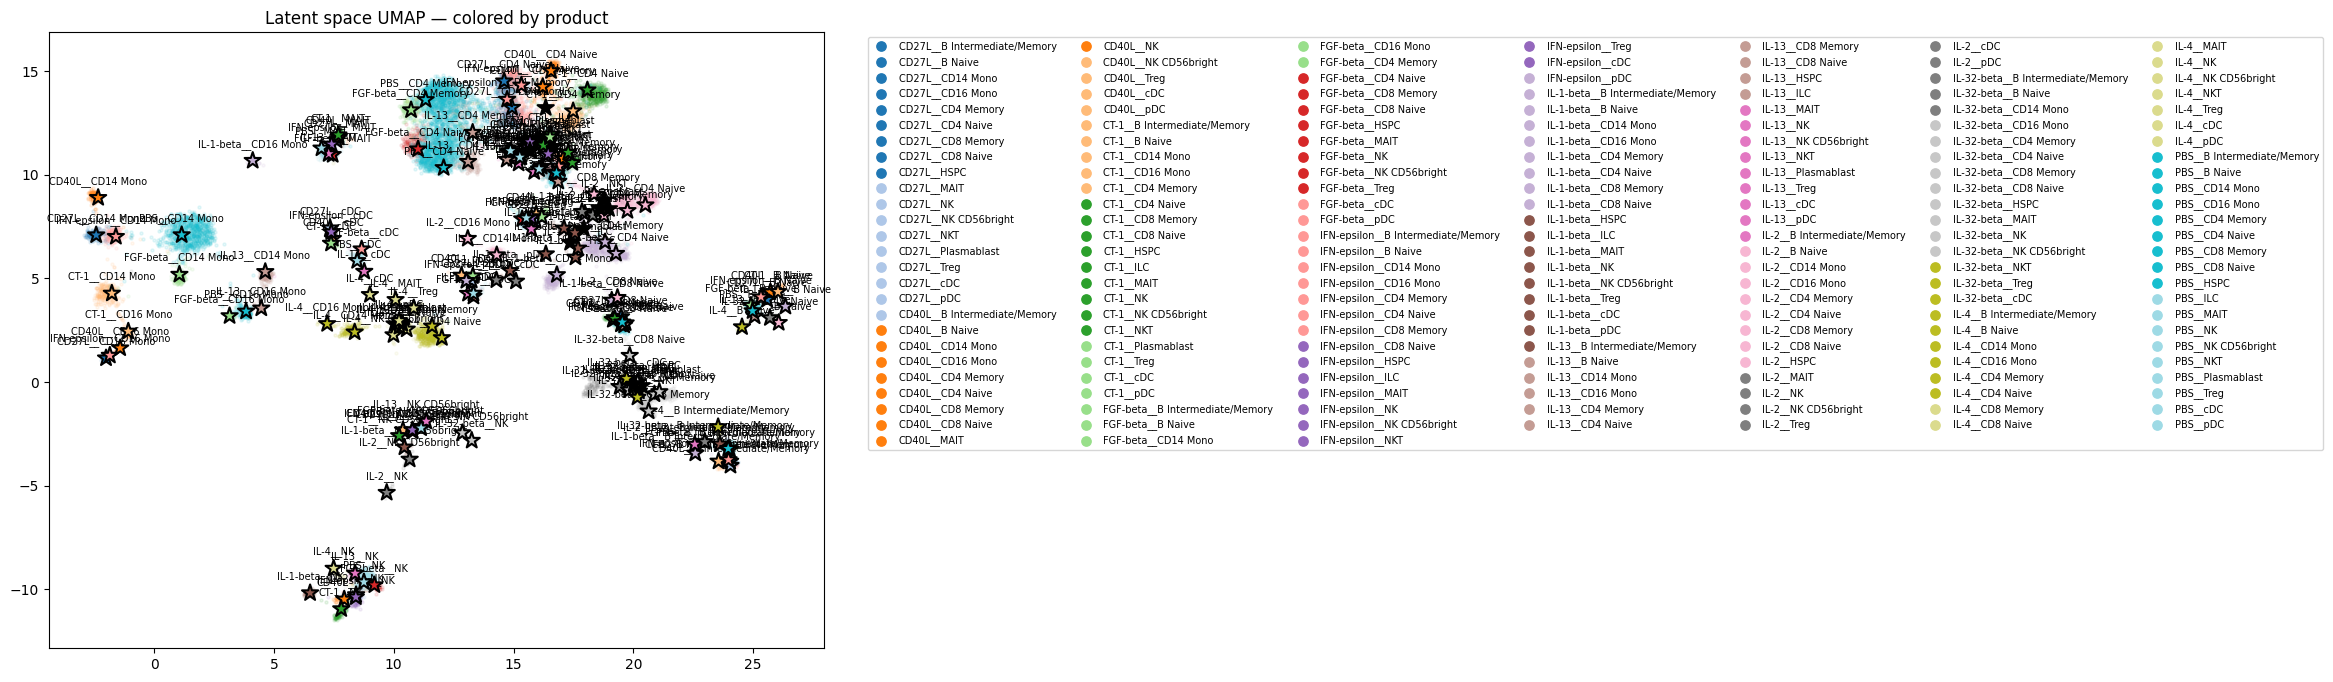

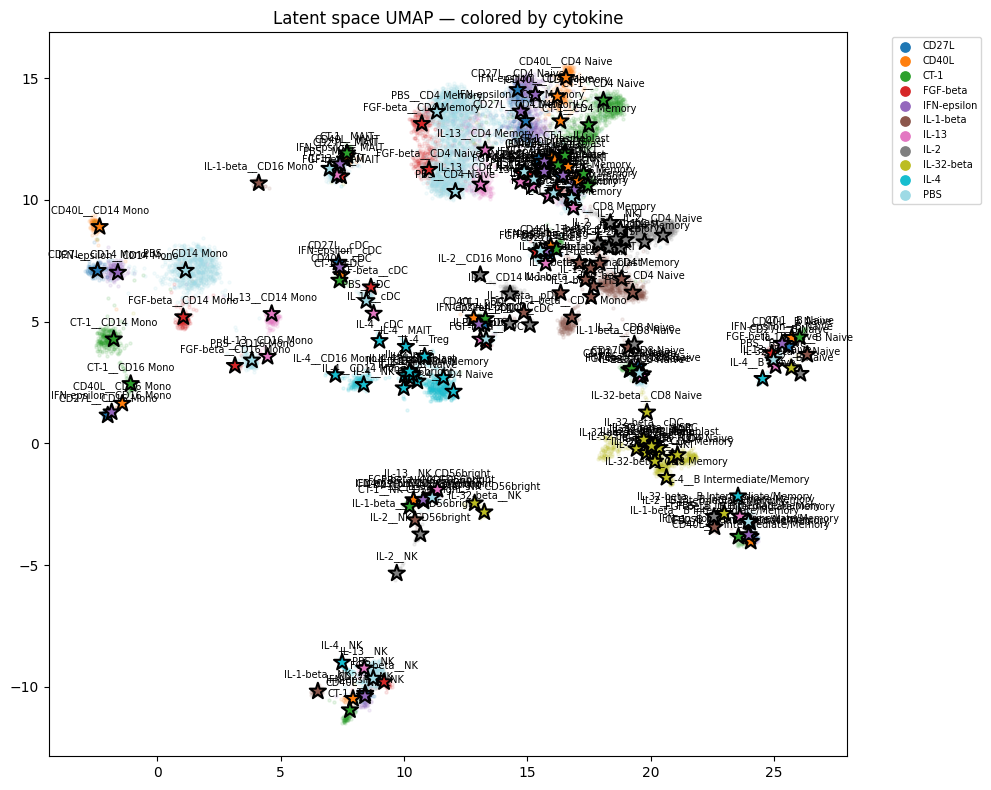

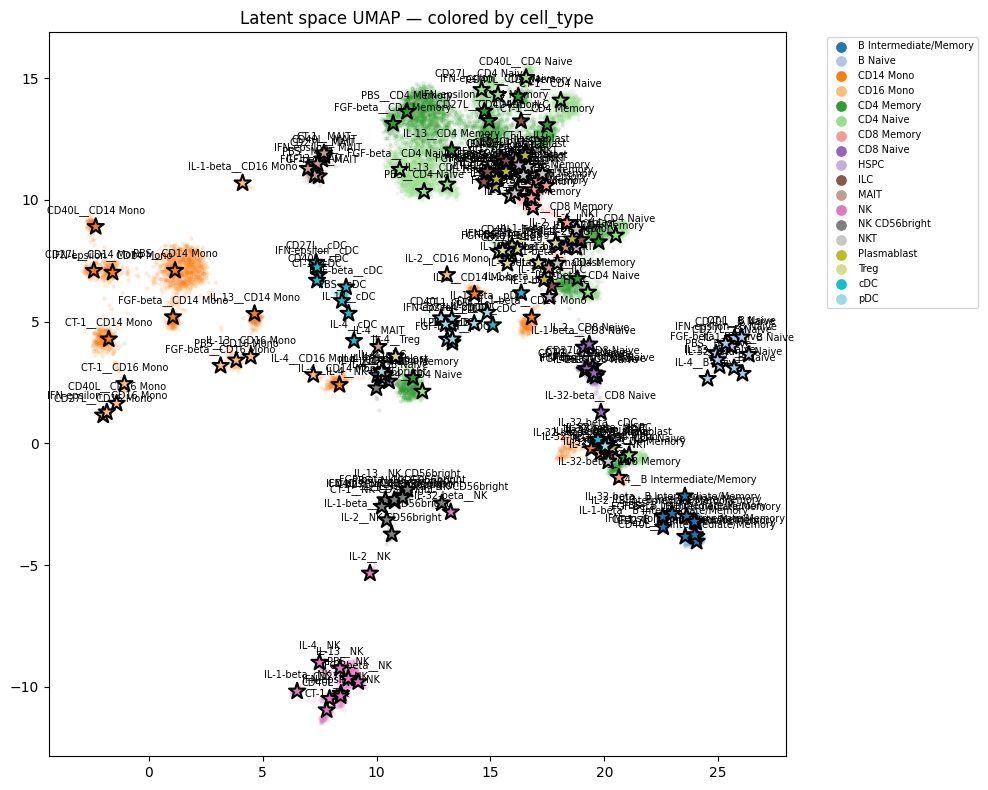

In [28]:
plot_latent_means_umap(analyzer)

#### 3.1.1 Latent Dimension Split UMAP

In [29]:
def plot_latent_dims_split_umap(analyzer, M, color=None, random_state=42):
    latent_adata = create_latent_adata(
        analyzer.adata,
        analyzer.model,
        analyzer.device,
        analyzer.conditions,
        analyzer.condition_type,
    )
    Z = latent_adata.X
    total_dims = Z.shape[1]

    if color is None:
        color = [analyzer.labels_key]

    splits = {
        f"dims_0-{M}": Z[:, :M],
        f"dims_{M}-{total_dims}": Z[:, M:],
    }

    for name, Z_split in splits.items():
        split_adata = ad.AnnData(X=Z_split.astype("float32"), obs=latent_adata.obs.copy())
        sc.pp.neighbors(split_adata)
        sc.tl.umap(split_adata, random_state=random_state)
        sc.pl.umap(split_adata, color=color, title=f"Latent UMAP — {name}")
        plt.savefig(
            os.path.join(analyzer.plot_dir, f"latent_umap_{name}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

In [30]:
print(analyzer.condition_type)

mixture


/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 464 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


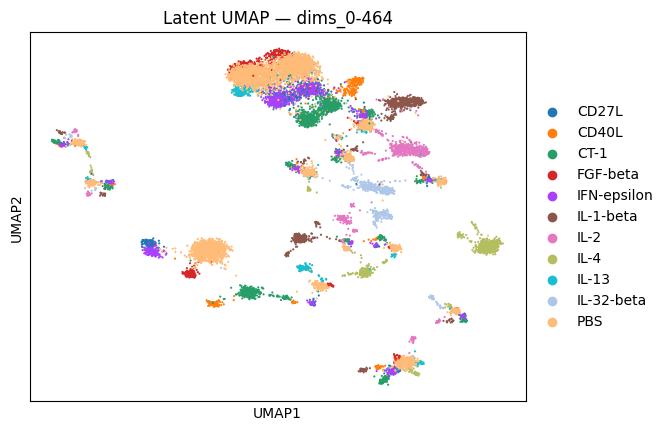

<Figure size 640x480 with 0 Axes>

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 1473 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


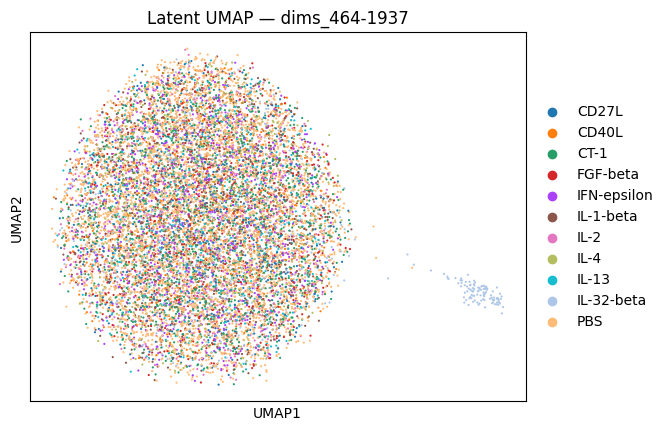

<Figure size 640x480 with 0 Axes>

In [31]:
if analyzer.condition_type == "mixture":
    M = analyzer.model.means_dim
else:
    M = 500
plot_latent_dims_split_umap(analyzer, M)

In [ ]:
def compare_learned_vs_empirical_means(analyzer):
    """Empirical latent mean per COMBO, aligned row-for-row with `model.means`.

    The rows of `model.means` are indexed by the combo vocabulary
    ("cytokine__cell_type"), so the empirical counterpart has to be grouped the same way.
    Masking `labels_key` (the cytokine column alone) with a combo label never matches, so
    every empirical mean was the mean of an empty selection - NaN - and PCA then rejected
    the input.

    Combos with no cells are dropped from both arrays: `combo_categories` is the full
    Cartesian product and ~20 of the 198 have no metacells at all, so their empirical
    mean is undefined. A held-out combo is NOT one of these - the holdout only left the
    training split, `analyzer.adata` still holds its cells.
    """
    latent_adata = create_latent_adata(
        analyzer.adata,
        analyzer.model,
        analyzer.device,
        analyzer.conditions,
        analyzer.condition_type,
    )
    Z = np.asarray(latent_adata.X)

    conditions = list(analyzer.conditions)
    labels = analyzer.combo_categories
    if labels is None:
        labels = analyzer.kwargs_data["dataset"].cats[0].categories.tolist()
    labels = list(labels)

    with torch.no_grad():
        learned = analyzer.model.means.cpu().numpy()
    if len(labels) != learned.shape[0]:
        raise ValueError(f"{len(labels)} combo labels but {learned.shape[0]} prior means")

    combo_of_cell = (
        analyzer.adata.obs[conditions].astype(str).agg("__".join, axis=1).to_numpy()
    )

    empirical, keep = [], []
    for i, label in enumerate(labels):
        mask = combo_of_cell == label
        if mask.sum() == 0:
            continue
        empirical.append(Z[mask].mean(axis=0))
        keep.append(i)

    print(f"{len(keep)} of {len(labels)} combos have cells "
          f"({len(labels) - len(keep)} empty, dropped)")
    return np.asarray(empirical), learned[keep], [labels[i] for i in keep]


def plot_learned_vs_empirical_means(empirical_means, learned_means, labels, analyzer,
                                    color_by=None, annotate=False):
    """PCA of empirical and learned means in one shared basis.

    Coloured by one condition rather than by combo - with ~178 combos a per-combo palette
    repeats and reads as noise. `color_by` defaults to the *non*-treatment condition
    (cell type), which is the dominant axis of latent structure; pass
    `analyzer.labels_key` to colour by cytokine instead. Each empirical/learned pair is
    joined by a line, so the length of that line is the per-combo error the plot is about.
    """
    conditions = list(analyzer.conditions)
    if color_by is None:
        color_by = next(c for c in conditions if c != analyzer.labels_key)
    if color_by not in conditions:
        raise ValueError(f"color_by={color_by!r} not in {conditions}")
    key_idx = conditions.index(color_by)
    groups = [l.split("__")[key_idx] for l in labels]
    levels = sorted(set(groups))

    n = len(empirical_means)
    combined = np.concatenate([empirical_means, learned_means], axis=0)
    if not np.isfinite(combined).all():
        raise ValueError("means contain NaN/inf - cannot PCA")

    pca = PCA(n_components=2)
    combined_2d = pca.fit_transform(combined)
    empirical_2d, learned_2d = combined_2d[:n], combined_2d[n:]

    cmap = plt.get_cmap("tab20", len(levels))
    color_of = {lvl: cmap(i) for i, lvl in enumerate(levels)}

    fig, ax = plt.subplots(figsize=(9, 7))
    for i, label in enumerate(labels):
        c = color_of[groups[i]]
        ax.plot(*zip(empirical_2d[i], learned_2d[i]), color=c, lw=0.6, alpha=0.5, zorder=1)
        ax.scatter(*empirical_2d[i], color=c, marker="o", s=45, zorder=2)
        ax.scatter(*learned_2d[i], color=c, marker="x", s=55, zorder=2)
        if annotate:
            ax.annotate(label, empirical_2d[i], fontsize=6, alpha=0.7)

    for lvl in levels:
        ax.scatter([], [], color=color_of[lvl], marker="s", label=lvl)
    ax.scatter([], [], color="black", marker="o", label="empirical")
    ax.scatter([], [], color="black", marker="x", label="learned")
    ax.legend(loc="best", fontsize=7, ncol=2)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title(f"Empirical vs. learned combo means (shared PCA basis, coloured by {color_by})")

    gap = np.linalg.norm(empirical_means - learned_means, axis=1)
    print(f"||empirical - learned|| per combo: median {np.median(gap):.3f}, "
          f"max {gap.max():.3f} ({labels[int(gap.argmax())]})")

    fig.tight_layout()
    plt.savefig(os.path.join(analyzer.plot_dir, "empirical_vs_learned_means.png"), dpi=300)
    plt.show()

In [ ]:
emp_means, learned_means, mean_labels = compare_learned_vs_empirical_means(analyzer)
plot_learned_vs_empirical_means(emp_means, learned_means, mean_labels, analyzer)

### 3.2 Counterfactuals

In [34]:
key = "IL-2"

In [35]:
x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(analyzer, key=key)

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

In [36]:
(
    cfs_classifier,
    cfs_train_dataloader,
    cfs_test_dataloader,
    cfs_train_dataset,
    cfs_adata_train,
    cfs_num_classes,
) = init_classifier(
    analyzer_cfs, key, latent=False, hidden_dim=None, labels_key="origin"
)

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier,
    cfs_train_dataloader,
    cfs_test_dataloader,
    weights,
    analyzer_cfs.device,
    num_epochs=10,
)

100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  7.01it/s]

Best Validation Accuracy: 0.8555


In [37]:
evaluate_training_error(
    analyzer, cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies
)

,Class,Accuracy
0,cfs,0.912288
1,original,0.103448


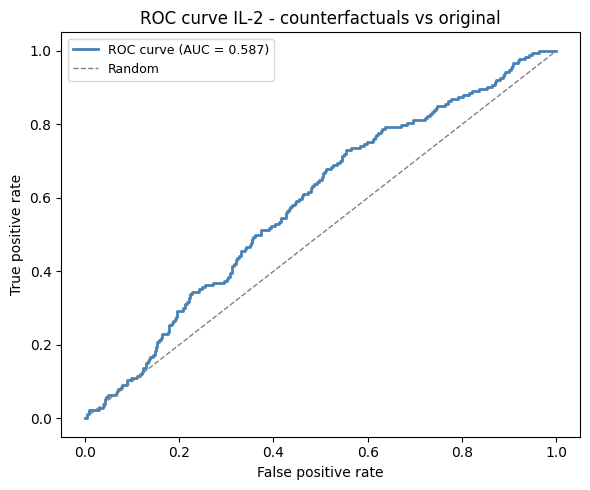

AUC: 0.587


In [38]:
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

### 3.3 MMD

In [39]:
ctrl_mmd = ctrl_mmd_dists(analyzer, key=key)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(analyzer, key=key, sigma=1.0)
print(f"Global MMD for {key}: {global_mmd}")

Control MMD (random split): 0.0017


100%|███████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 13.76it/s]

Global MMD for IL-2: 0.001378774642944336


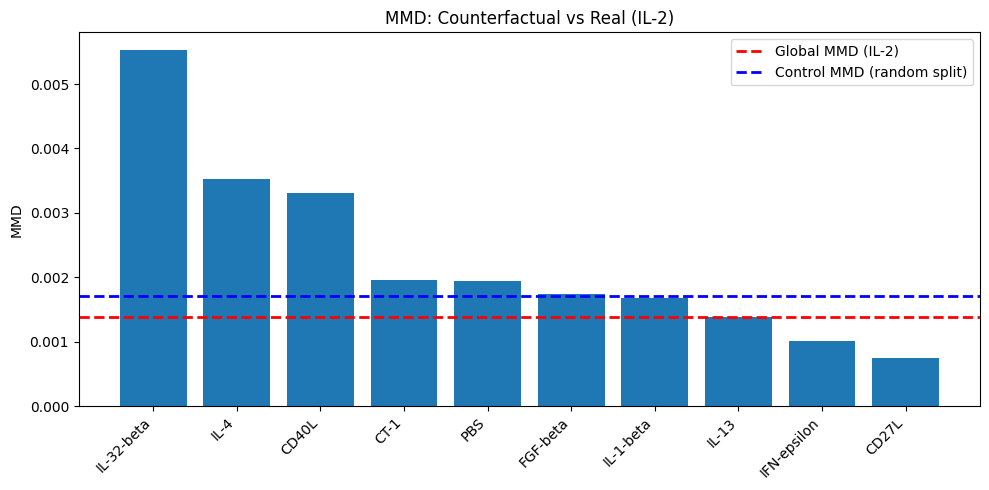

In [40]:
plot_mmd_dists(analyzer, ctrl_mmd, global_mmd, mmd_per_group, key=key)

### 3.4 Mean Expressions

In [41]:
key = "CT-1"

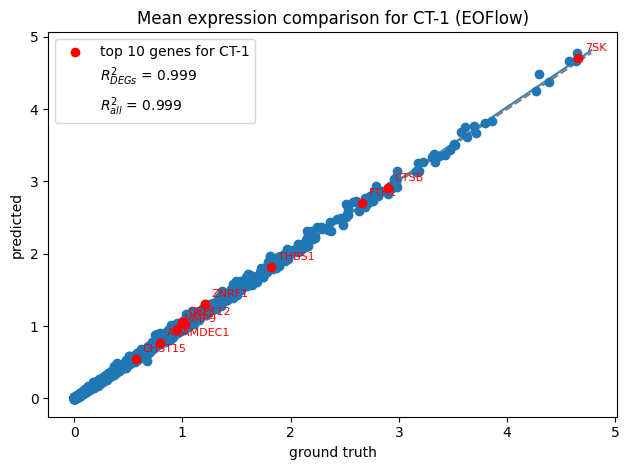

In [42]:
plot_mean_expression_comparison(analyzer, key=key, top_n=10, method="EOFlow")

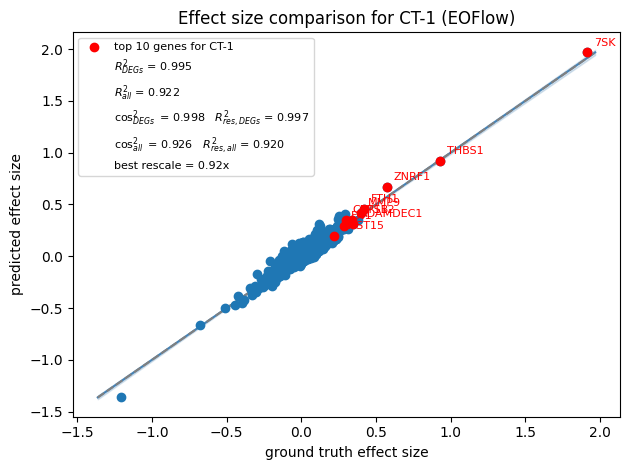

In [43]:
plot_effect_size_comparison(analyzer, key=key, top_n=10, method="EOFlow", cfs_fn=generate_counterfactuals)

### 3.5 Violin Plots

In [44]:
key = "IL-2"

In [45]:
from src.analysis.logistic_regression import generate_counterfactuals
from src.utils.utils import extract_top_genes, normalize_log1p
import scanpy as sc
import pandas as pd


def plot_top_deg_violin(
    analyzer, key, cfs_fn=generate_counterfactuals, log1p_transform=False, gene_idx=0
):
    top_gene_names, gene_indices = extract_top_genes(
        analyzer, key, top_n=20, log1p_transform=log1p_transform
    )
    gene_name = top_gene_names[gene_idx]
    gene_idx = gene_indices[gene_idx]

    def gene_values(adata_subset):
        x = (
            adata_subset.X.toarray()
            if hasattr(adata_subset.X, "toarray")
            else adata_subset.X
        )
        if log1p_transform:
            x = normalize_log1p(x)
        return x[:, gene_idx]

    control_values = gene_values(
        analyzer.adata[
            analyzer.adata.obs[analyzer.labels_key] == analyzer.control_label
        ]
    )
    key_values = gene_values(
        analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key]
    )

    x_cfs, z_cfs, all_source_labels, _ = cfs_fn(analyzer, key=key)
    # counterfactual = control cells predicted forward to `key`, matching the classic
    # ctrl -> stim comparison (rather than pooling counterfactuals from every source)
    cf_mask = np.asarray(all_source_labels) == analyzer.control_label
    cf_values = (
        x_cfs[cf_mask, gene_idx]
        .clip(
            min=0, max=1.1 * np.quantile(x_cfs[cf_mask, gene_idx].cpu().numpy(), 0.999)
        )
        .cpu()
        .numpy()
    )

    cf_label = f"{key} (counterfactual)"
    order = [analyzer.control_label, cf_label, key]
    values = np.concatenate([control_values, cf_values, key_values]).astype(np.float32)
    groups = (
        [analyzer.control_label] * len(control_values)
        + [cf_label] * len(cf_values)
        + [key] * len(key_values)
    )

    violin_adata = ad.AnnData(
        X=values.reshape(-1, 1),
        var=pd.DataFrame(index=[str(gene_name)]),
        obs=pd.DataFrame({"group": pd.Categorical(groups, categories=order)}),
    )

    ax = sc.pl.violin(
        violin_adata,
        keys=str(gene_name),
        groupby="group",
        order=order,
        use_raw=False,
        xlabel="",
        ylabel="expression",
        show=False,
    )
    ax.set_title(f"Top DEG for {key}: {gene_name}")
    plt.tight_layout()
    plt.savefig(os.path.join(analyzer.plot_dir, f"top_deg_violin_{key}.png"), dpi=300)
    plt.show()

/scratch/jobs/61204201/ipykernel_1955853/4001132797.py:74: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


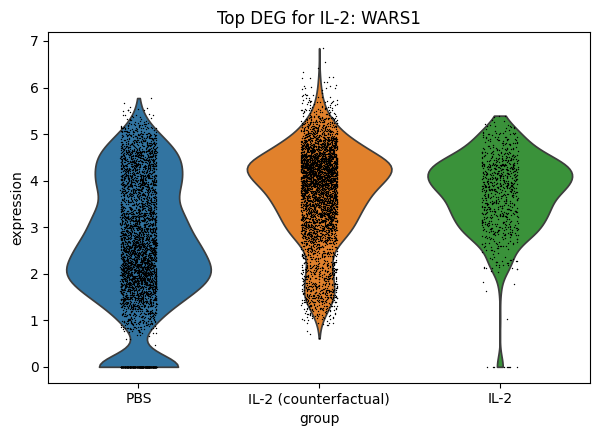

In [46]:
plot_top_deg_violin(analyzer, key=key, gene_idx=0)

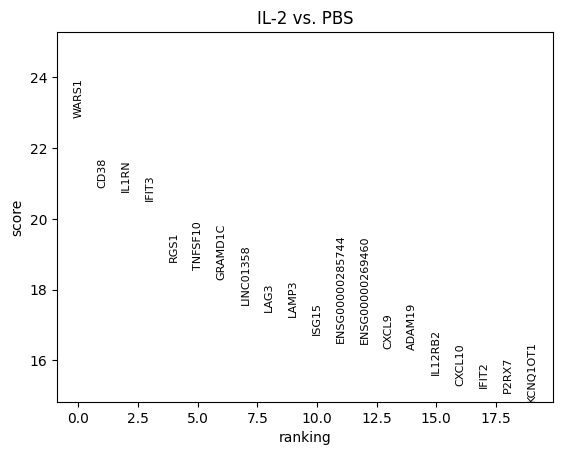

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/tools/_dendrogram.py:138: UserWarning: You’re trying to run this on 1937 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  _choose_representation(adata, use_rep=use_rep, n_pcs=n_pcs)


categories: CD27L, CD40L, CT-1, etc.
var_group_labels: IL-2


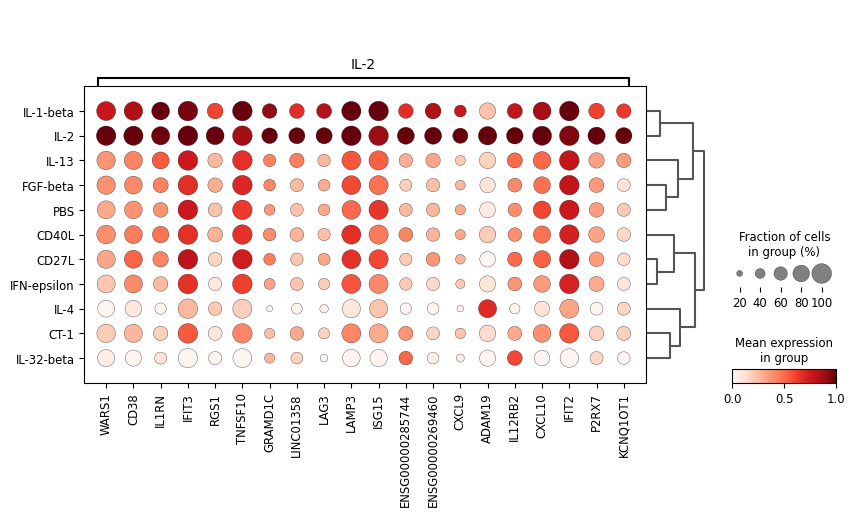

In [47]:
import scanpy as sc

sc.tl.rank_genes_groups(
    adata,
    groupby=analyzer.labels_key,
    groups=[key],
    reference=analyzer.control_label,
    method="wilcoxon",
)
sc.pl.rank_genes_groups(adata)
sc.pl.rank_genes_groups_dotplot(
    adata, groupby=f"{analyzer.labels_key}", standard_scale="var", n_genes=20
)

### 3.6 CF UMAP

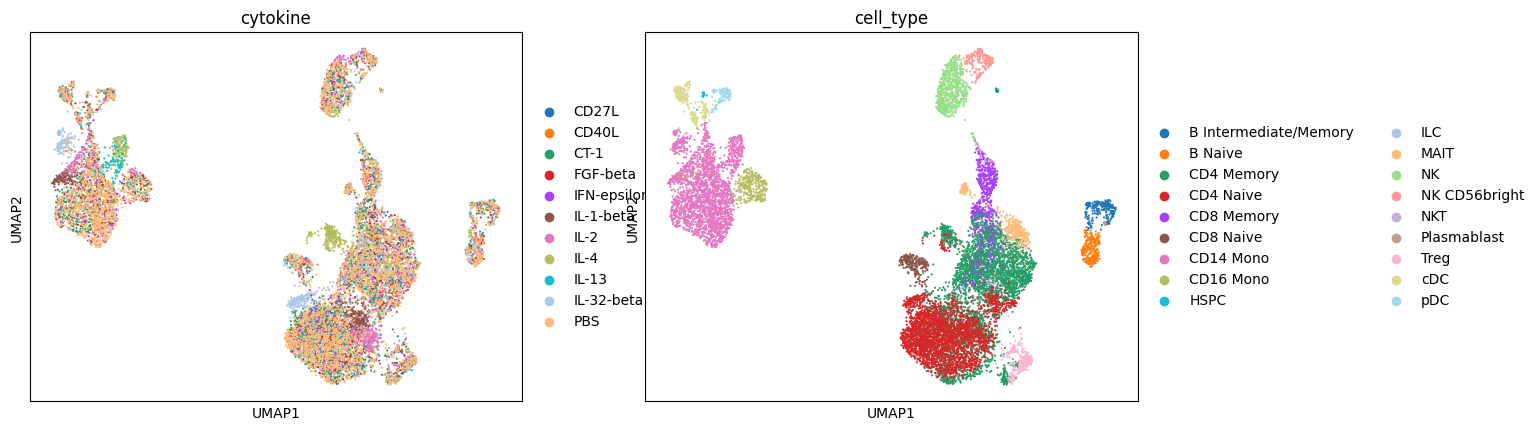

/home/jhoefer/sandbox/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 1937 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


<Figure size 640x480 with 0 Axes>

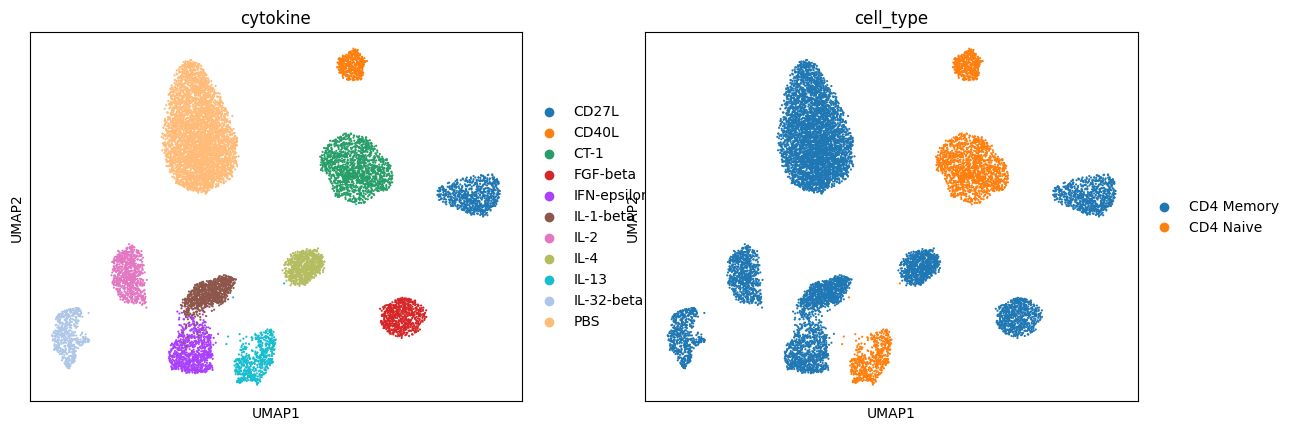

<Figure size 640x480 with 0 Axes>

In [48]:
adata_sampled = sample_from_means(analyzer, sigma=1.0)

sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=[f"{labels_key}", "cell_type"])
plt.savefig(os.path.join(analyzer.plot_dir, f"umap_original.png"), dpi=300)

sc.pp.neighbors(adata_sampled)
sc.tl.umap(adata_sampled)
sc.pl.umap(adata_sampled, color=[f"{labels_key}", "cell_type"])
plt.savefig(os.path.join(analyzer.plot_dir, f"umap_sampled.png"), dpi=300)

## 4. Cytokine Effects

### 4.1 Bottlenecks

In [19]:
def get_perturbation_dim_importance(analyzer, perturbation, control_label=None, trick=False):
    """
    Rank latent dimensions by their importance for a specific perturbation,
    based on the displacement of the perturbation mean from the control mean.
    """
    if control_label is None:
        control_label = analyzer.control_label

    dataset = analyzer.kwargs_data["dataset"]
    categories = dataset.cats[0].categories.tolist()
    means = analyzer.model.means.detach().cpu()  # (K, N_dim)

    pert_idx = categories.index(perturbation)
    ctrl_idx = categories.index(control_label)
    if trick:
        pert_idx += 1

    pert_mean = means[pert_idx]  # (N_dim,)
    ctrl_mean = means[ctrl_idx]  # (N_dim,)

    # displacement vector: how much does this perturbation shift each dim
    delta = pert_mean - ctrl_mean  # (N_dim,)

    # rank by absolute displacement
    importance = torch.abs(delta)
    dim_order = torch.argsort(importance, descending=True)

    return dim_order.numpy(), delta.numpy()

In [20]:
if analyzer.jac_dec is None:
    analyzer.compute_jacobian()

before forward: 2931.0 MiB
after forward: 3158.8 MiB


KeyboardInterrupt: 

In [ ]:
RANDOM = True
MEANS = False
pert = "IL-4"
trick = True

In [ ]:
perturbations = adata.obs[labels_key].unique()
perturbations = [c for c in perturbations if c != control_label]

FULL_DE = False

keep_dims = [N_dim, 1700, 1500, 1000, 750, 500, 250, 100, 75, 50, 25, 10, 5, 3, 0]
vae_bottlenecks = []

if RANDOM:
    analyzer.latent_sort = torch.randperm(N_dim)
    analyzer.latent_sort = torch.arange(N_dim)  
elif MEANS:
    if pert is None:
        raise ValueError("Please specify a perturbation for MEANS sorting.")
    else:
        perturbations = [pert]
        analyzer.latent_sort, _ = get_perturbation_dim_importance(
            analyzer, perturbation=pert, control_label=control_label, trick=trick
        )

In [ ]:
(
    rhos,
    direction_agreements,
    top_overlaps,
    lfc_shifts,
    rhos_pca,
    direction_agreements_pca,
    top_overlaps_pca,
    lfc_shifts_pca,
    rhos_vae,
    direction_agreements_vae,
    top_overlaps_vae,
    lfc_shifts_vae,
) = evaluate_de_effects(
    analyzer,
    perturbations,
    keep_dims,
    vae_bottlenecks,
    batch_size=1024,
    use_noise=False,
    FULL_DE=FULL_DE,
)

In [ ]:
metrics = [
    ("Spearman Rho", rhos, rhos_pca),
    ("Direction Agreement", direction_agreements, direction_agreements_pca),
    ("Top 100 Overlap", top_overlaps, top_overlaps_pca),
    ("LFC Shift", lfc_shifts, lfc_shifts_pca),
]

colors = [
    f"tab:{c}"
    for c in ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray"]
]

fig, axes = plt.subplots(len(metrics), 2, figsize=(10, 5 * len(metrics)), sharey="row")

for row, (label, flow_vals, pca_vals) in enumerate(metrics):
    for col, (vals, linestyle, tag) in enumerate(
        [
            (flow_vals, "solid", "Flow"),
            (pca_vals, "dashed", "PCA"),
        ]
    ):
        a = axes[row, col]
        for i, pert in enumerate(perturbations):
            a.plot(
                keep_dims,
                vals.T[i],
                marker="o",
                color=colors[i % len(colors)],
                linestyle=linestyle,
                label=pert,
            )
        a.set_title(f"{label} — {tag}")
        a.set_xlabel("First n nonzero Latent Dims")
        a.set_ylabel(label)
        a.legend()
        a.grid()

plt.suptitle("DE Result Stability vs. Number of Latent Dims", fontsize=14)
plt.tight_layout()

de = "full" if FULL_DE else "lfc"
postfix = "_means" if MEANS else ""
postfix += "_random" if RANDOM else ""
postfix += "_trick" if trick else ""
name = f"DE_stability_vs_latent_dims_{de}_{postfix}"
plt.savefig(os.path.join(analyzer.plot_dir, f"{name}.png"))
plt.show()

### 4.3 Enrichment: does the learned cytokine shift match known biology?

`enrichment_analysis.bulk_enrichment_analysis` (the older notebooks) enriches the
**decoder Jacobian**, rows = latent dims, so it reports what each latent *axis* means.
Under the factorized prior that is the wrong unit: the cytokine effect is not an axis,
it is a vector - `mu(cy, ct) - mu(PBS, ct)`, one shared treatment direction rescaled by
`w_ct` under `treatment_gain`. So what gets enriched here is the **gene-space image of
that shift**, one signed signature per (cytokine, cell type):

    pred = mean(decode(encode(x_PBS,ct) + shift)) - mean(x_PBS,ct)   # the model
    real = mean(x_cy,ct)                          - mean(x_PBS,ct)   # the data

`.X` is log1p-normalized, so both differences are log fold changes - what ULM wants.

Three separate claims, in this order:

1. **Positive controls** - does the model's shift rank the textbook pathway near the top?
   IL-2 -> IL2_STAT5_SIGNALING, IFN-epsilon -> INTERFERON_ALPHA, the TNF-superfamily
   ligands (CD40L, CD27L) and IL-1-beta/IL-32-beta -> TNFA_SIGNALING_VIA_NFKB, CT-1 (a
   gp130 ligand) -> IL6_JAK_STAT3. Read `rank_pred`, not `score_pred`: a raw ULM t-value
   is not comparable across cell types with different control-pool sizes, but "first out
   of 39" is. **FGF-beta carries no expectation and is the negative control.**
2. **Agreement with the data** (`agreement`) - Spearman rho between the predicted and
   real pathway profiles. Independent of claim 1: the model can reproduce exactly what
   the data shows in a cell type where the data is not textbook.
3. **Specificity** (`n_perm`) - gene labels are permuted to give the scores a threshold
   to beat. The gene universe is 1937 HVGs already selected on this dataset, not the
   genome, so the analytic ULM p-value is optimistic about what "significant" means.

Two things to keep in view when reading the output: scores are relative among those
HVGs, and only ~39 of the 50 hallmark sets clear decoupler's `tmin` at this gene count -
`n_covered` says how many genes each expected set actually had here.

[nets] hallmark: 50 sets (cached)
[nets] progeny: 14 sets (cached)
[signatures] 50 predicted, 50 with real ground truth, over 5 cell types
[enrichment] 39 of 50 hallmark sets cleared decoupler's tmin on 1937 genes
[null] 50/200 permutations
[null] 100/200 permutations
[null] 150/200 permutations
[null] 200/200 permutations
[null] |score| 95th percentile under permuted gene labels: 1.91

Expected pathway rank (predicted shift): top-1 0/50, top-5 6/50, median rank 33 of 39
  same statistic on the real data:  top-1 2/50, top-5 12/50, median rank 23
Predicted vs real pathway profile: median rho 0.810 (50/50 positive)
Negative controls ['FGF-beta']: median rho 0.662 over 5 combo(s)


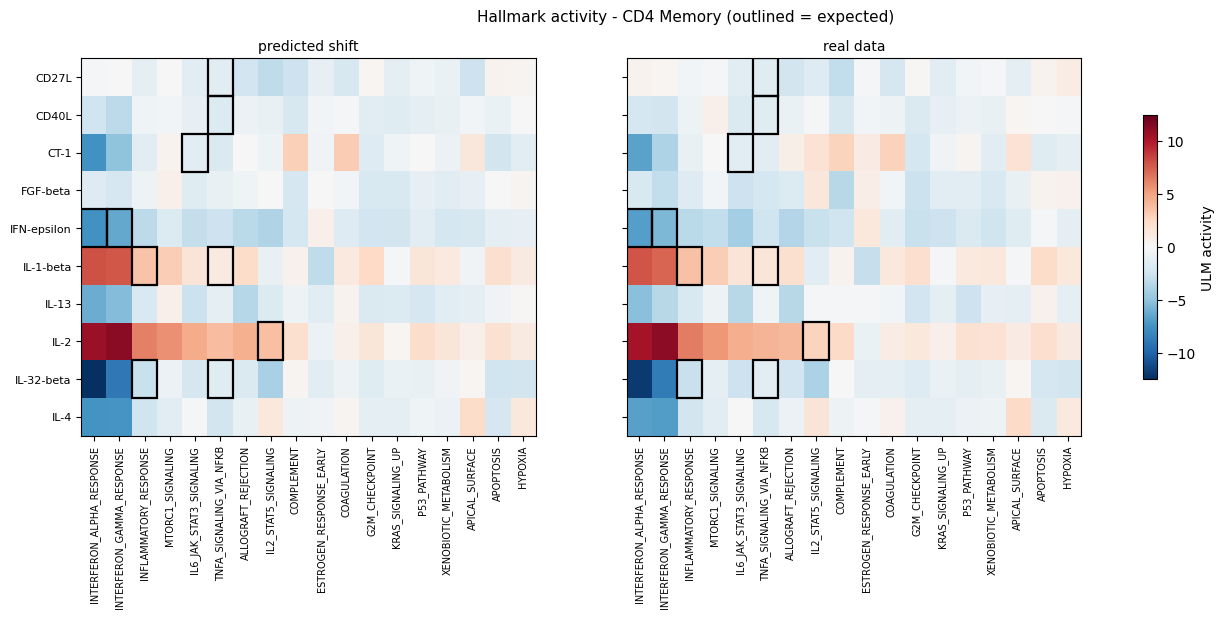

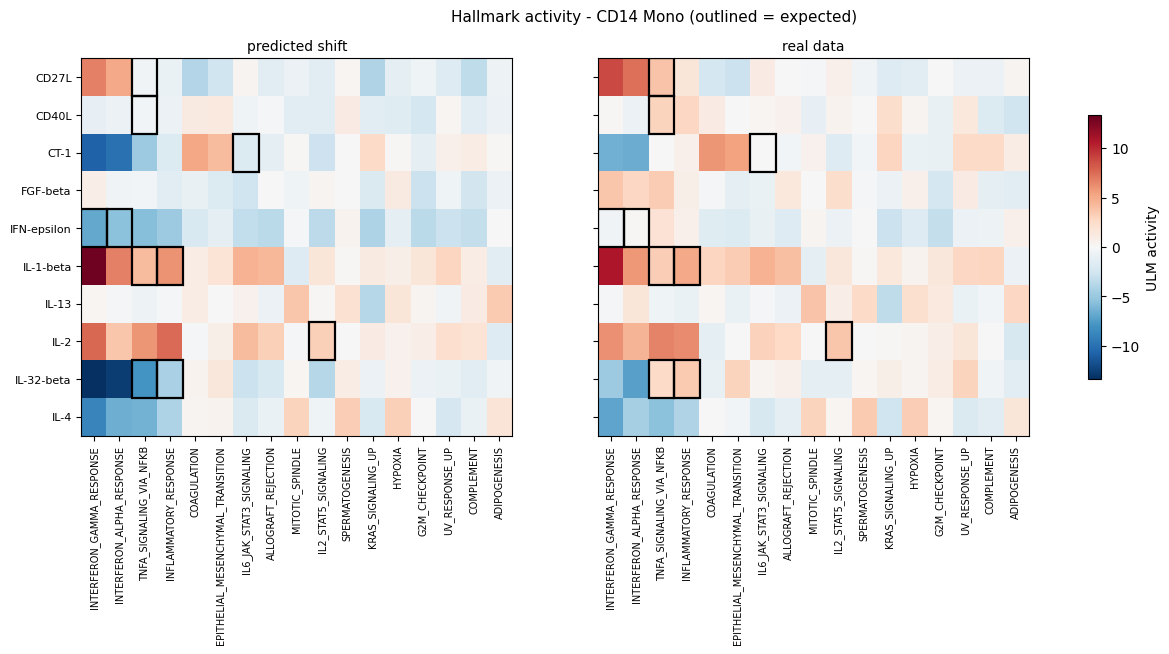

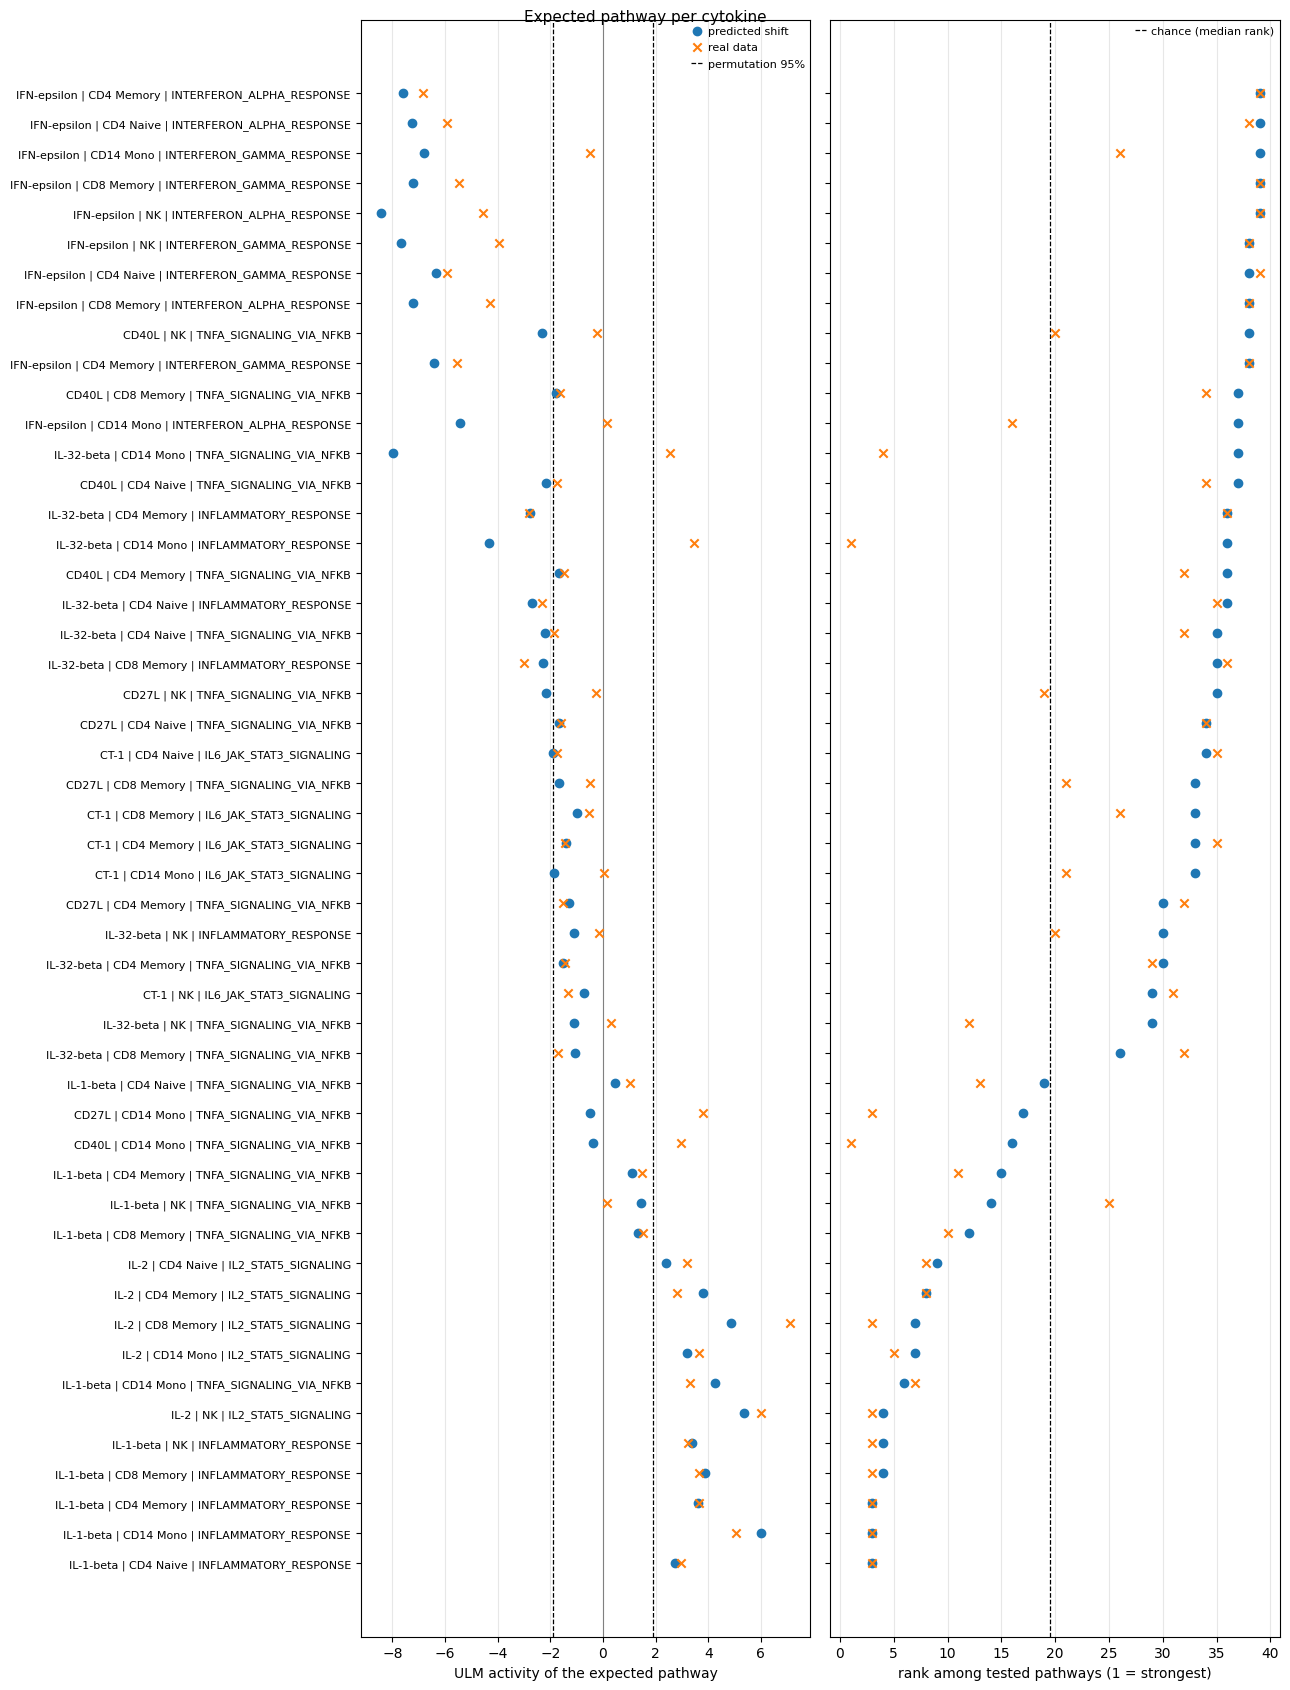

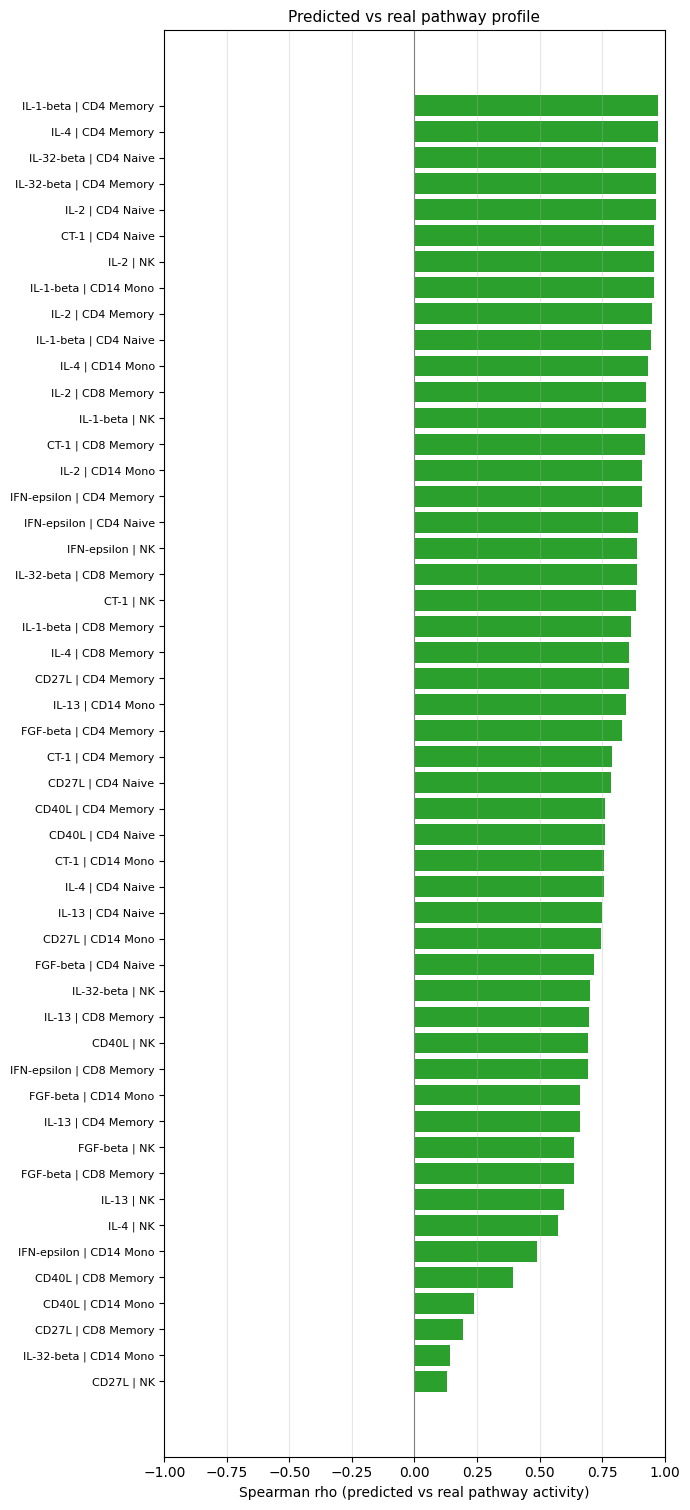

,row,cytokine,cell_type,pathway,score_pred,score_real,rank_pred,rank_real,padj_pred,padj_real,n_covered_pred,n_tested_pred,p_perm
0,CD27L | CD14 Mono,CD27L,CD14 Mono,TNFA_SIGNALING_VIA_NFKB,-0.479906,3.813706,17,3,8.377339e-01,1.836010e-03,46,39,0.572543
1,CD27L | CD4 Memory,CD27L,CD4 Memory,TNFA_SIGNALING_VIA_NFKB,-1.304771,-1.508712,30,32,6.882629e-01,5.879444e-01,46,39,0.140086
2,CD27L | CD4 Naive,CD27L,CD4 Naive,TNFA_SIGNALING_VIA_NFKB,-1.667589,-1.608153,34,34,6.211339e-01,6.242314e-01,46,39,0.073393
3,CD27L | CD8 Memory,CD27L,CD8 Memory,TNFA_SIGNALING_VIA_NFKB,-1.661451,-0.483897,33,21,5.392303e-01,9.620835e-01,46,39,0.073993
4,CD27L | NK,CD27L,NK,TNFA_SIGNALING_VIA_NFKB,-2.170161,-0.271192,35,19,2.281986e-01,8.951573e-01,46,39,0.030697
5,CD40L | CD14 Mono,CD40L,CD14 Mono,TNFA_SIGNALING_VIA_NFKB,-0.380833,2.971949,16,1,8.953974e-01,6.804173e-02,46,39,0.655634
6,CD40L | CD4 Memory,CD40L,CD4 Memory,TNFA_SIGNALING_VIA_NFKB,-1.675708,-1.477480,36,32,7.227768e-01,6.810929e-01,46,39,0.072493
7,CD40L | CD4 Naive,CD40L,CD4 Naive,TNFA_SIGNALING_VIA_NFKB,-2.144425,-1.748660,37,34,4.176001e-01,5.233141e-01,46,39,0.031797
8,CD40L | CD8 Memory,CD40L,CD8 Memory,TNFA_SIGNALING_VIA_NFKB,-1.793550,-1.619252,37,34,6.837266e-01,4.811538e-01,46,39,0.058794
9,CD40L | NK,CD40L,NK,TNFA_SIGNALING_VIA_NFKB,-2.301024,-0.220695,38,20,3.491623e-01,9.772558e-01,46,39,0.025597


In [ ]:


# cached to disk on first call - dc.op.* downloads from omnipathdb (and needs the same
# unverified-SSL workaround the old enrichment code used), so a compute node without
# outbound network would otherwise fail this cell
nets = load_nets(cache_dir="/g/stegle/jhoefer/data/decoupler_nets")

# the abundant cell types (>500 metacells each), so the empirical `real` signature the
# prediction is scored against is itself reliable. HSPC/ILC/Plasmablast have <20 and
# would only add noise to the agreement statistic.
ENRICH_CELL_TYPES = ["CD4 Memory", "CD4 Naive", "CD14 Mono", "NK", "CD8 Memory"]

enr = analyze_shift_enrichment(
    analyzer,
    cell_types=ENRICH_CELL_TYPES,
    nets=nets,
    net_name="hallmark",
    n_perm=200,
    heatmap_cell_types=["CD4 Memory", "CD14 Mono"],
    clamp_min=None,
)
enr["expected"]

[signatures] 50 predicted, 50 with real ground truth, over 5 cell types
[enrichment] 14 of 14 progeny sets cleared decoupler's tmin on 1937 genes
[null] 50/200 permutations
[null] 100/200 permutations
[null] 150/200 permutations
[null] 200/200 permutations
[null] |score| 95th percentile under permuted gene labels: 1.96

Expected pathway rank (predicted shift): top-1 5/65, top-5 16/65, median rank 13 of 14
  same statistic on the real data:  top-1 8/65, top-5 21/65, median rank 12
Predicted vs real pathway profile: median rho 0.903 (49/50 positive)
Negative controls ['FGF-beta']: median rho 0.697 over 5 combo(s)


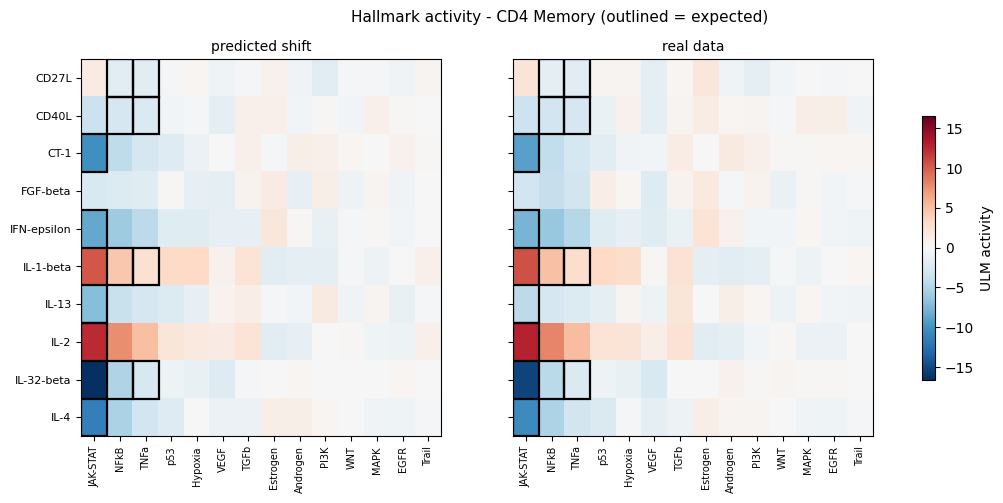

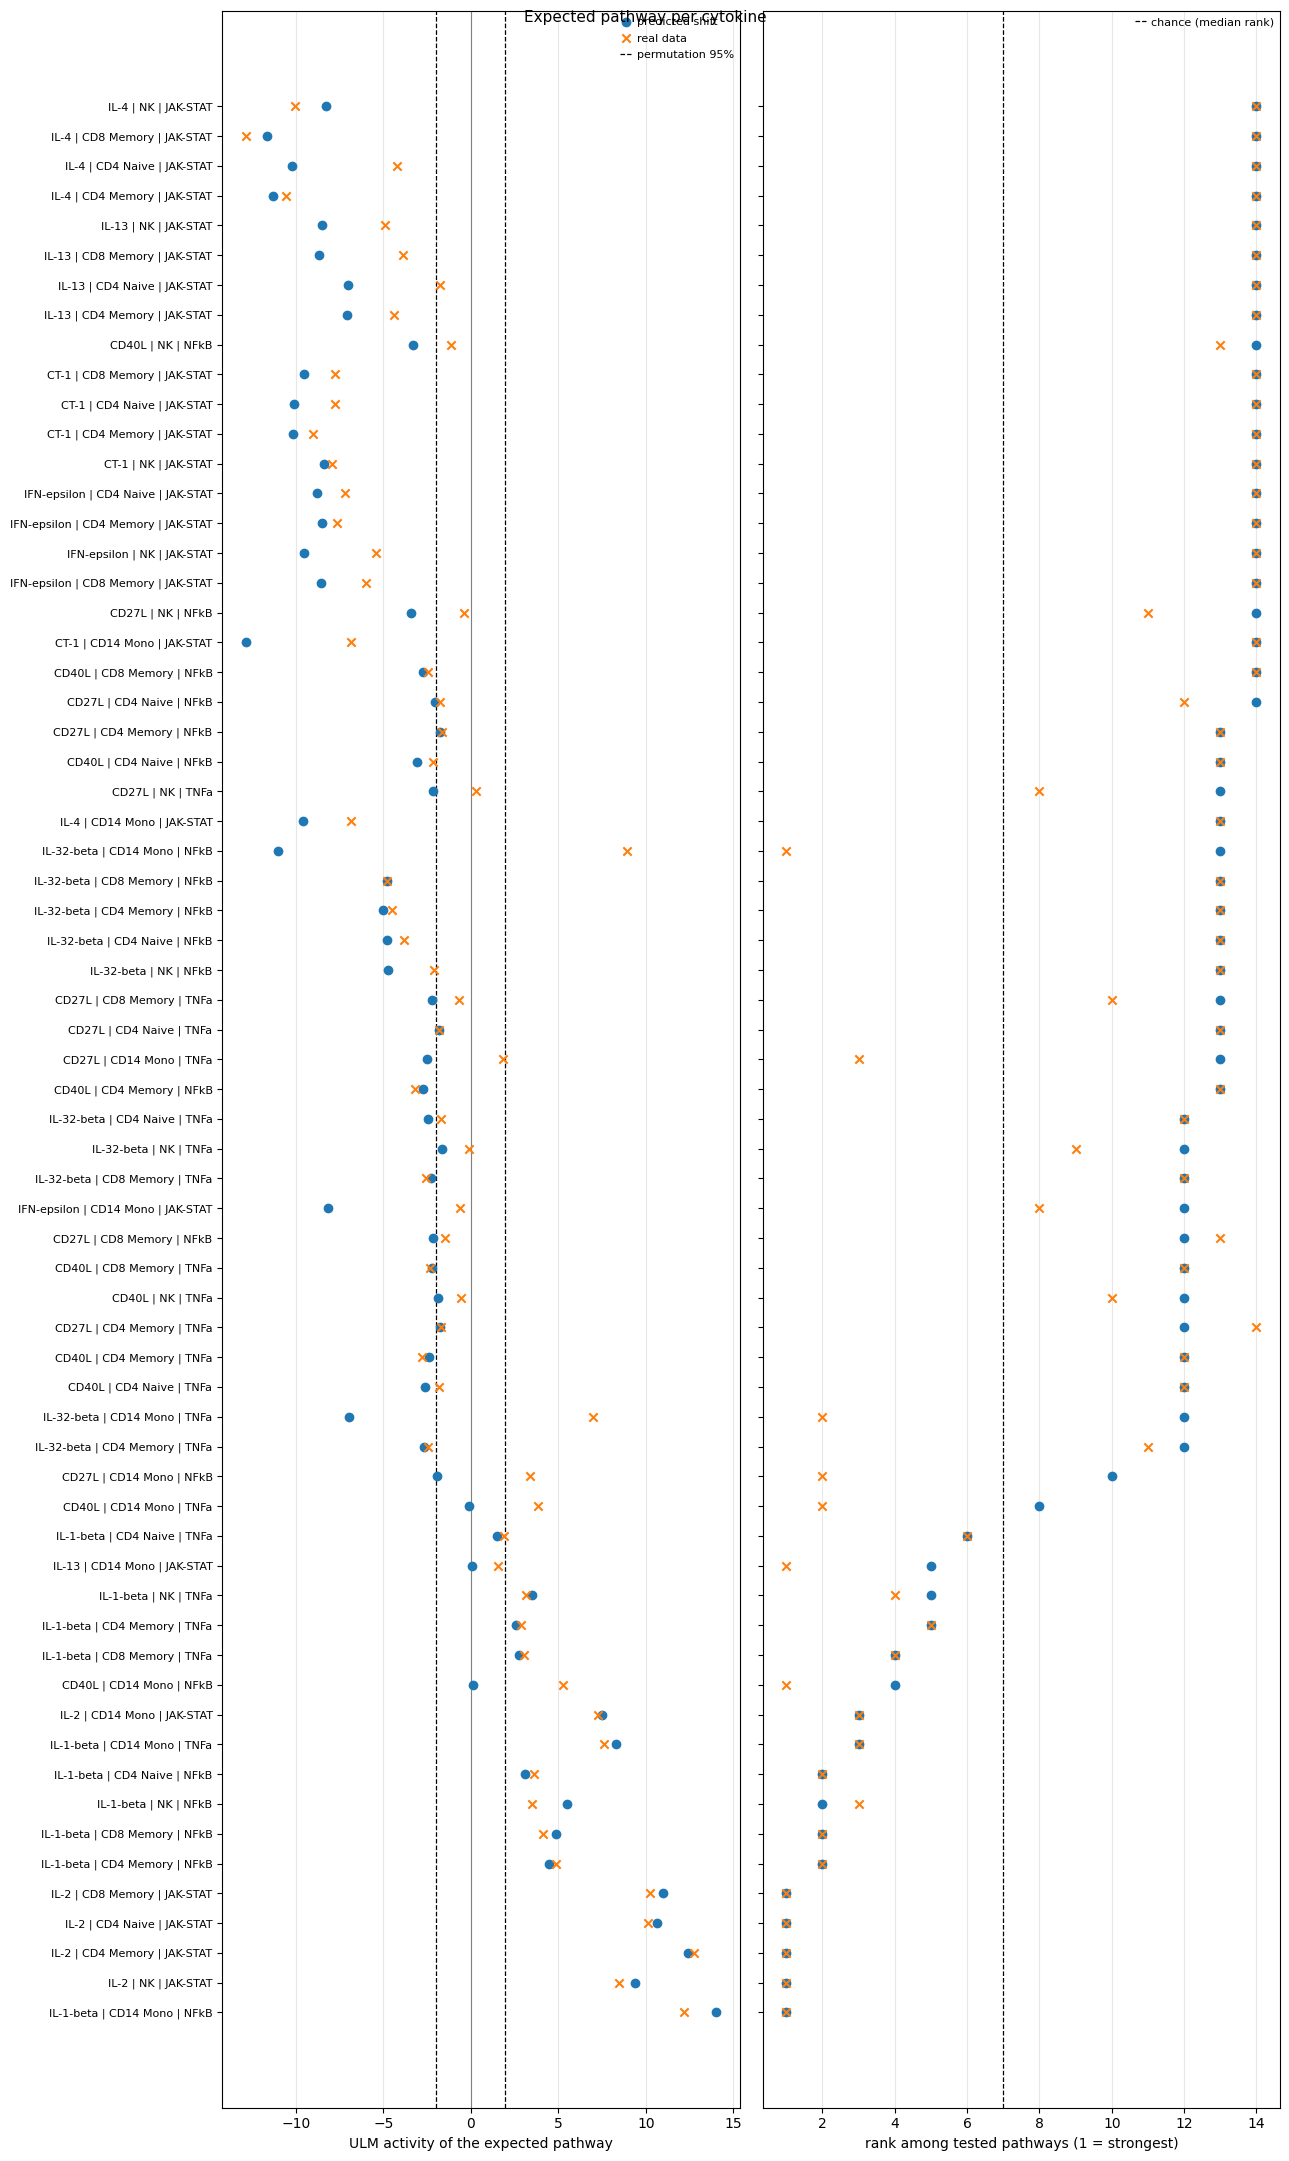

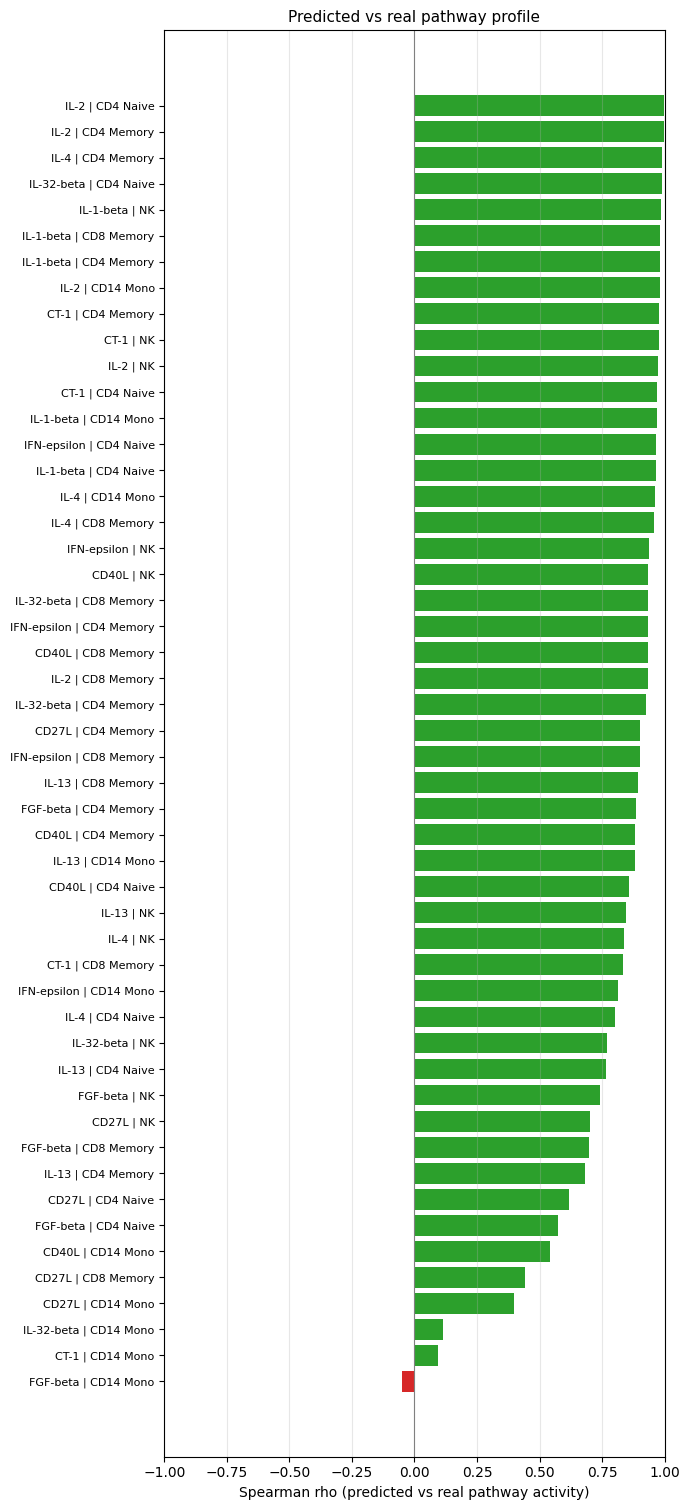

,row,cytokine,cell_type,pathway,score_pred,score_real,rank_pred,rank_real,padj_pred,padj_real,n_covered_pred,n_tested_pred,p_perm
0,CD27L | CD14 Mono,CD27L,CD14 Mono,NFkB,-1.920075,3.378530,10,2,1.283223e-01,5.203367e-03,497,14,0.052195
1,CD27L | CD14 Mono,CD27L,CD14 Mono,TNFa,-2.511701,1.843190,13,3,5.644769e-02,1.832757e-01,381,14,0.018998
2,CD27L | CD4 Memory,CD27L,CD4 Memory,NFkB,-1.761353,-1.627497,13,13,3.925209e-01,3.237590e-01,497,14,0.067693
3,CD27L | CD4 Memory,CD27L,CD4 Memory,TNFa,-1.728202,-1.715497,12,14,3.925209e-01,3.237590e-01,381,14,0.072593
4,CD27L | CD4 Naive,CD27L,CD4 Naive,NFkB,-2.066173,-1.759104,14,12,4.886123e-01,3.673576e-01,497,14,0.039496
...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,IL-4 | CD14 Mono,IL-4,CD14 Mono,JAK-STAT,-9.587120,-6.868186,13,13,1.869269e-20,6.130058e-11,142,14,0.000700
61,IL-4 | CD4 Memory,IL-4,CD4 Memory,JAK-STAT,-11.285948,-10.541582,14,14,1.658097e-27,3.774722e-24,142,14,0.000100
62,IL-4 | CD4 Naive,IL-4,CD4 Naive,JAK-STAT,-10.193055,-4.203585,14,14,1.176528e-22,3.847349e-04,142,14,0.000300
63,IL-4 | CD8 Memory,IL-4,CD8 Memory,JAK-STAT,-11.615967,-12.855278,14,14,4.688517e-29,3.411446e-35,142,14,0.000100


In [ ]:
# PROGENy: 14 signalling programmes instead of 50 broad hallmarks, and the only readout
# for IL-4 and IL-13 - they act through STAT6 and have no hallmark set of their own, so
# their row is empty in EXPECTED_HALLMARK by design.
enr_pw = analyze_shift_enrichment(
    analyzer,
    cell_types=ENRICH_CELL_TYPES,
    nets=nets,
    net_name="progeny",
    expected=EXPECTED_PROGENY,
    n_perm=200,
    heatmap_cell_types=["CD4 Memory"],
    clamp_min=None,
)
enr_pw["expected"]

In [ ]:
# `b_cy` is one vector shared across cell types by construction, so the only sources of
# cell-type specificity in the prediction are the gain `w_ct` and the decoder's
# nonlinearity. One cytokine across every cell type tests whether that is enough to
# generate cell-type-appropriate biology - e.g. IL-1-beta inflammatory in CD14 Mono and
# muted in CD4 Naive - or whether the shift decodes to the same programme everywhere.
CY = "IL-1-beta"

rows = enr["meta"].index[enr["meta"]["cytokine"] == CY]
display(enr["agreement"][enr["agreement"]["cytokine"] == CY])

# strongest pathways for this cytokine, cell type by cell type; a near-identical column
# in every cell type is the failure mode to look for
profile = enr["acts_pred"].loc[rows].T
profile.columns = [r.split(" | ")[1] for r in rows]
profile.reindex(profile.abs().max(axis=1).nlargest(15).index).round(2)

,row,spearman_rho,p,n_pathways,cytokine,cell_type
0,IL-1-beta | CD4 Memory,0.975506,6.204993e-26,39,IL-1-beta,CD4 Memory
7,IL-1-beta | CD14 Mono,0.956680,2.018069e-21,39,IL-1-beta,CD14 Mono
9,IL-1-beta | CD4 Naive,0.946761,8.412075e-20,39,IL-1-beta,CD4 Naive
12,IL-1-beta | NK,0.925101,3.863962e-17,39,IL-1-beta,NK
20,IL-1-beta | CD8 Memory,0.865182,1.210035e-12,39,IL-1-beta,CD8 Memory


,CD4 Memory,CD4 Naive,CD14 Mono,NK,CD8 Memory
INTERFERON_GAMMA_RESPONSE,7.74,5.87,12.94,9.23,10.06
INTERFERON_ALPHA_RESPONSE,7.97,6.11,6.71,9.55,8.63
INFLAMMATORY_RESPONSE,3.60,2.74,6.02,3.38,3.86
ALLOGRAFT_REJECTION,2.26,1.72,4.43,5.47,4.60
IL6_JAK_STAT3_SIGNALING,1.61,1.11,4.66,1.94,2.34
TNFA_SIGNALING_VIA_NFKB,1.11,0.46,4.27,1.43,1.32
MTORC1_SIGNALING,3.10,2.51,0.58,3.17,3.84
APOPTOSIS,1.99,1.68,2.72,2.98,3.75
ANGIOGENESIS,0.48,0.16,-3.18,0.40,0.27
ESTROGEN_RESPONSE_EARLY,-3.13,-2.38,-0.12,-2.12,-2.51


## 5. OOD

In [21]:
# the checkpoint's own set, not the notebook's: it is what this model actually held
# out, and with a ten-combo file the two can disagree if HOLDOUT_FILE was edited.
holdout_combo = list(model_config.holdout_combos or [])

# 5.x evaluates one combo. Prefer the notebook's, so the section title and the
# figures agree; fall back to the checkpoint's first with a warning rather than
# silently scoring a combo the model was trained on.
ood_combo = HOLDOUT_COMBO if HOLDOUT_COMBO in holdout_combo else holdout_combo[0]
if ood_combo != HOLDOUT_COMBO:
    print(f"WARNING: {HOLDOUT_COMBO} is not in the checkpoint's holdout set; "
          f"section 5 falls back to {ood_combo}.")

print(f"Checkpoint held out {len(holdout_combo)} combo(s); evaluating {ood_combo}")

estimate_leftout_combo_mean(
    model=analyzer.model,
    combo_categories=model_config.combo_categories,
    conditions=["cytokine", "cell_type"],
    holdout_combo=ood_combo,
    condition_key="cytokine",
    control_label="PBS",
    cell_type_key="cell_type",
    observed_combos=observed_combos,
)

Checkpoint held out 10 combo(s); evaluating {'cytokine': 'IL-2', 'cell_type': 'CD8 Memory'}


tensor([ 0.4678,  0.0518, -0.5988,  ...,  0.0000,  0.0000,  0.0000],
       device='cuda:0')

### 5.1 Sampling strategy 1: Normal around the estimated mean

Draw fresh latent points from an isotropic Normal centered on the mean estimated above, then decode.

In [22]:
adata_ood_normal = sample_leftout_combo_normal(
    model=analyzer.model,
    combo_categories=model_config.combo_categories,
    conditions=["cytokine", "cell_type"],
    holdout_combo=ood_combo,
    condition_key="cytokine",
    control_label="PBS",
    cell_type_key="cell_type",
    observed_combos=observed_combos,
    n_samples=500,
    sigma=1.0,
    var=analyzer.adata.var,
    clamp_min=None,
)
adata_ood_normal

AnnData object with n_obs × n_vars = 500 × 1937
    obs: 'cytokine', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'

### 5.2 Sampling strategy 2: encode control cells, shift, decode

Take real `PBS`-treated cells of the held-out cell type, encode them, shift by the same average treatment-control latent shift used above, then decode - this carries over each real cell's own latent structure instead of drawing fresh isotropic noise.

In [23]:
adata_ood_shift = sample_leftout_combo_shift(
    model=analyzer.model,
    adata=analyzer.adata,
    combo_categories=model_config.combo_categories,
    conditions=["cytokine", "cell_type"],
    holdout_combo=ood_combo,
    condition_key="cytokine",
    control_label="PBS",
    cell_type_key="cell_type",
    observed_combos=observed_combos,
    clamp_min=None,
)
adata_ood_shift

AnnData object with n_obs × n_vars = 195 × 1937
    obs: 'cytokine', 'cell_type'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_counts', 'highly_variable_rank', 'variances', 'variances_norm'

### 5.3 Evaluation: MMD and mean expressions

Compares both OOD sampling strategies against the real held-out-combo cells - present in
`analyzer.adata` even though the model never trained on them, since only the training
script's `split_holdout_combinations` call excluded them, not `load_data`.

`scoped_analyzer_for_combo` restricts `.adata` to just the held-out cell type so
`analyzer.labels_key` ("cytokine") alone resolves to this combo, letting the same MMD and
mean-expression helpers used for the regular counterfactual evaluation (sections 3.3/3.4)
be reused unchanged via `cfs_fn_from_adata`.

In [24]:
ood_key = ood_combo["cytokine"]

scoped_analyzer = scoped_analyzer_for_combo(
    analyzer,
    ood_combo,
    conditions=["cytokine", "cell_type"],
    condition_key="cytokine",
    cell_type_key="cell_type",
)

ood_predictions = {
    "Normal": adata_ood_normal,
    "Shift": adata_ood_shift,
}

print(f"Real held-out cells found: {scoped_analyzer.adata.obs['cytokine'].value_counts()[ood_key]}")

Real held-out cells found: 34


100%|████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 26761.80it/s]

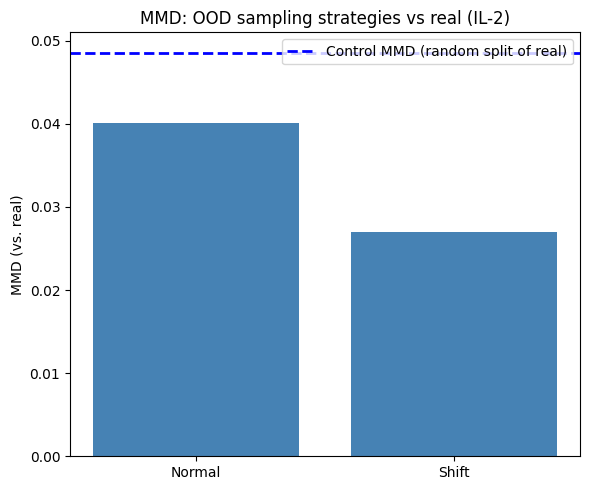

Control MMD (random split of real): 0.0486
{'Normal': 0.04013657569885254, 'Shift': 0.027002811431884766}


In [25]:
mmd_results, ood_ctrl_mmd = evaluate_leftout_combo_mmd(
    scoped_analyzer, ood_predictions, key=ood_key, plot_dir=analyzer.plot_dir
)
print(f"Control MMD (random split of real): {ood_ctrl_mmd:.4f}")
print(mmd_results)

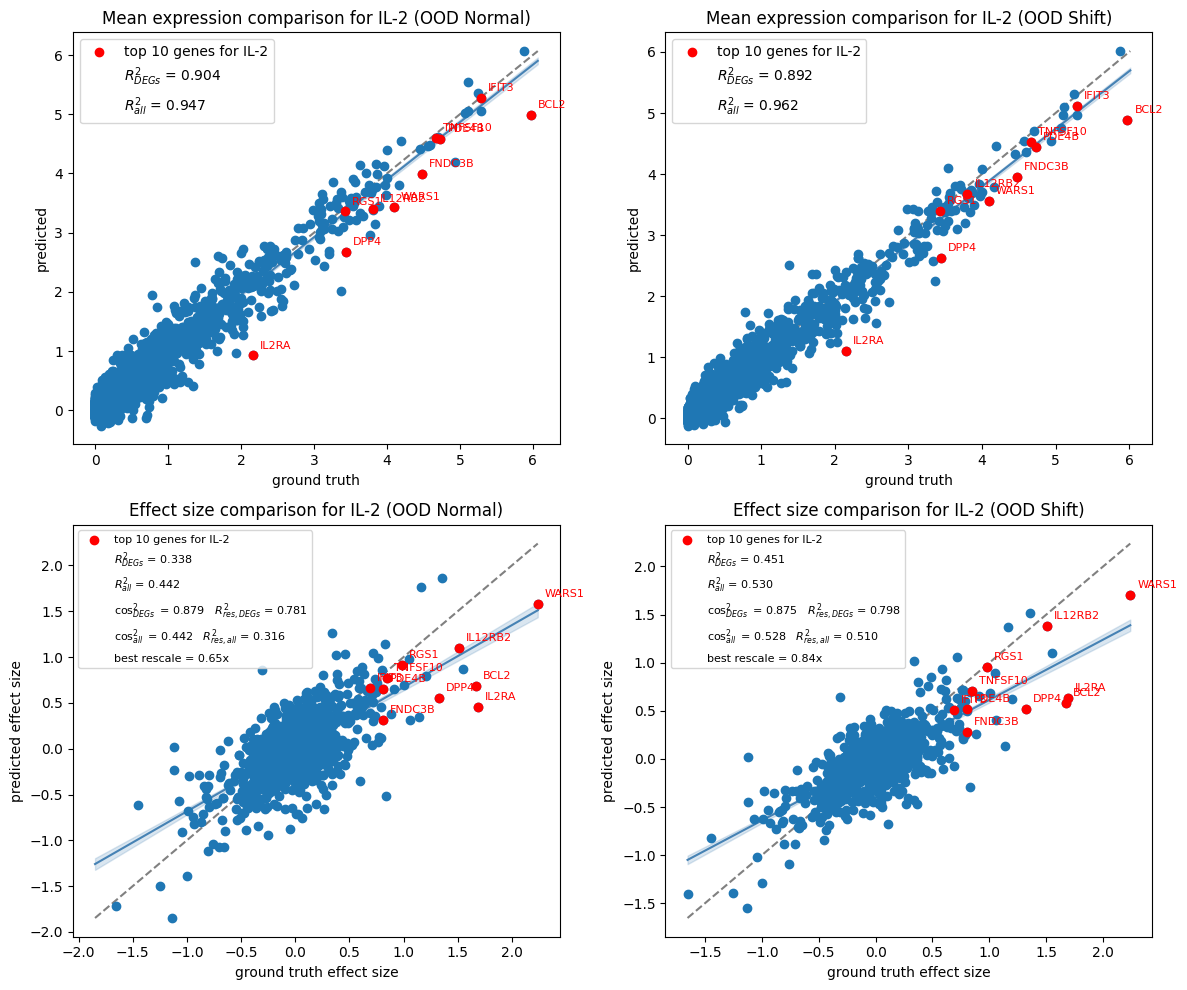

In [26]:
fig, axes = plt.subplots(
    2, len(ood_predictions), figsize=(6 * len(ood_predictions), 10), squeeze=False
)  # squeeze=False: keeps `axes` 2-D even with a single prediction

for col, (name, adata_pred) in enumerate(ood_predictions.items()):
    cfs_fn = cfs_fn_from_adata(adata_pred, source_label=name)

    plot_mean_expression_comparison(
        scoped_analyzer, key=ood_key, top_n=10, cfs_fn=cfs_fn, method=f"OOD {name}", ax=axes[0, col]
    )
    plot_effect_size_comparison(
        scoped_analyzer, key=ood_key, top_n=10, cfs_fn=cfs_fn, method=f"OOD {name}", ax=axes[1, col]
    )

plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"leftout_combo_mean_expression_{ood_key}.png"), dpi=300)
plt.show()

### 5.4 OOD enrichment: the right biology for a combo the model never saw

The payoff. The model never trained on (IL-2, CD8 Memory) - does its predicted shift
still put IL2_STAT5 first *for that cell type*, and does the whole pathway profile match
the real held-out cells? This is the claim the factorized prior exists to support: the
treatment factor `b_cy` is fitted from the other cell types, so a held-out combo's mean
is composed rather than guessed.

`baseline=enr` adds `rank_pred_in_dist` - the median rank the same cytokine's expected
pathway reached in the cell types the model *did* train on. That is the comparison worth
reading: it separates "prediction degrades off the training design" from "this pathway
was never findable on an HVG background in the first place". The permutation null is
reused from section 4.3 rather than re-estimated on 10 rows, where it would be far
noisier.

`holdout_combos` comes from the checkpoint, not from `HOLDOUT_FILE` - it is what this
model actually held out, and the file can have been edited since the run.

In [27]:
ood_enr = analyze_holdout_enrichment(
    analyzer,
    model_config.holdout_combos or HOLDOUT_LIST,
    baseline=enr,
    nets=nets,
    net_name="hallmark",
    clamp_min=None,
)
ood_enr["expected"]

NameError: name 'enr' is not defined

### 5.5 Where the composed means land

Every combo has a learned prior mean `mu = a_ct + b_cy` and an empirical one - the mean of
its cells after encoding. For a combo the flow trained on, the NLL pulls those together
directly. For a **held-out** combo there is no such pull: `mu` is composed from factors
fitted on *other* combos, and nothing ever told the encoder to send those cells there. The
distance between the two is therefore a direct, latent-space read of the composition error
the factorized prior is built to control - no sampling, no decoding, no MMD in between.

Three things this plot has to get right, each of which made the earlier §3.1 version
misleading:

- **Condition block only.** `model.means` is exactly zero in dims `[means_dim:]` (the
  fixed `means_zero` buffer), while the empirical mean there is finite-sample noise of
  size `sqrt((N_dim - means_dim)/n)`. Comparing full vectors put ~50% of the squared
  distance into dims where the model is *correctly* zero.
- **The schedule-free eval iterate.** `AdamWScheduleFree` leaves the *training* point `y`
  in the parameters; the trained model is the averaged point `x`, which only
  `optimizer.eval()` materialises. The encoder and the means sit in different parameter
  groups and move by different amounts (measured: 8.0% vs 4.1%), so their alignment - the
  very thing measured here - changes. Skipping it nearly doubled the apparent gap.
- **Sample size.** The gap correlates with `n` at Spearman -0.77, so combos with a handful
  of metacells look miscalibrated when they only have a noisy empirical mean. Combos below
  `MIN_CELLS` are dropped and `n` is on the x axis rather than hidden.

In [64]:
from scipy.stats import spearmanr

MIN_CELLS = 20

# AdamWScheduleFree stores the training iterate in the parameters; measuring alignment
# between the encoder and the prior means requires the evaluation (x) iterate. Idempotent
# - schedulefree guards on its own `train_mode` flag. Belongs in section 2.2 really; it is
# here so this cell is correct even if that cell has not been updated.
if any(g.get("train_mode") for g in optimizer.param_groups):
    optimizer.eval()
    print("switched the model to the schedule-free eval (x) iterate")


def combo_mean_gaps(analyzer, holdout_combos, min_cells=MIN_CELLS):
    """Per combo: ||empirical latent mean - learned prior mean|| over the condition block."""
    conditions = list(analyzer.conditions)
    labels = list(analyzer.combo_categories)
    means_dim = analyzer.model.means_dim

    Z = np.asarray(
        create_latent_adata(
            analyzer.adata, analyzer.model, analyzer.device,
            conditions, analyzer.condition_type,
        ).X
    )[:, :means_dim]
    with torch.no_grad():
        learned = analyzer.model.means.cpu().numpy()[:, :means_dim]

    held = {"__".join(str(c[k]) for k in conditions) for c in (holdout_combos or [])}
    combo_of_cell = (
        analyzer.adata.obs[conditions].astype(str).agg("__".join, axis=1).to_numpy()
    )

    rows = []
    for i, label in enumerate(labels):
        mask = combo_of_cell == label
        n = int(mask.sum())
        if n < min_cells:
            continue
        rows.append({
            "combo": label, "n": n, "held_out": label in held,
            "gap": float(np.linalg.norm(Z[mask].mean(0) - learned[i])),
            "learned_norm": float(np.linalg.norm(learned[i])),
        })
    return pd.DataFrame(rows).sort_values("gap", ascending=False).reset_index(drop=True)


gaps = combo_mean_gaps(analyzer, model_config.holdout_combos or HOLDOUT_LIST)
tr, he = gaps[~gaps.held_out], gaps[gaps.held_out]
print(f"{len(gaps)} combos with >= {MIN_CELLS} metacells "
      f"({len(he)} held out, {len(tr)} trained), means_dim={analyzer.model.means_dim}")
print(f"  trained  median gap {tr.gap.median():.3f}")
print(f"  held-out median gap {he.gap.median():.3f}   "
      f"({he.gap.median() / tr.gap.median():.2f}x)")
print(f"  trained combos above the held-out median: {int((tr.gap > he.gap.median()).sum())}/{len(tr)}")
print(f"  Spearman(gap, n) = {spearmanr(gaps.n, gaps.gap)[0]:+.3f}")

83 combos with >= 20 metacells (10 held out, 73 trained), means_dim=58
  trained  median gap 0.762
  held-out median gap 2.379   (3.12x)
  trained combos above the held-out median: 0/73
  Spearman(gap, n) = -0.303


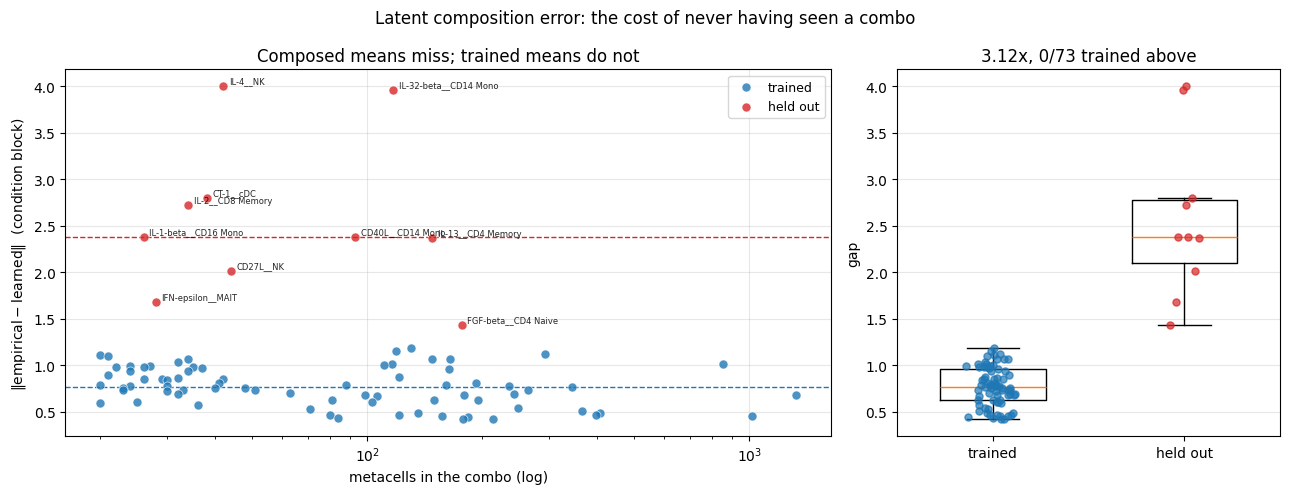

,combo,n,gap,learned_norm
0,IL-4__NK,42,4.003,9.961
1,IL-32-beta__CD14 Mono,117,3.959,9.047
2,CT-1__cDC,38,2.798,9.551
3,IL-2__CD8 Memory,34,2.719,8.606
4,IL-1-beta__CD16 Mono,26,2.382,9.225
5,CD40L__CD14 Mono,93,2.376,7.367
6,IL-13__CD4 Memory,148,2.363,5.648
7,CD27L__NK,44,2.012,7.981
8,IFN-epsilon__MAIT,28,1.674,7.911
9,FGF-beta__CD4 Naive,177,1.437,6.215


In [65]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5),
                         gridspec_kw={"width_ratios": [2, 1]})

a = axes[0]
for held, sub, c, lbl in [(False, tr, "tab:blue", "trained"),
                          (True, he, "tab:red", "held out")]:
    a.scatter(sub.n, sub.gap, s=42, alpha=0.8, color=c, label=lbl,
              edgecolor="white", linewidth=0.5, zorder=3)
a.axhline(tr.gap.median(), color="tab:blue", ls="--", lw=1)
a.axhline(he.gap.median(), color="tab:red", ls="--", lw=1)
for _, r in he.iterrows():
    a.annotate(r.combo, (r.n, r.gap), fontsize=6, alpha=0.85,
               xytext=(4, 2), textcoords="offset points")
a.set_xscale("log")
a.set_xlabel("metacells in the combo (log)")
a.set_ylabel(r"$\|\mathrm{empirical} - \mathrm{learned}\|$  (condition block)")
a.set_title("Composed means miss; trained means do not")
a.legend(fontsize=9)
a.grid(alpha=0.3)

b = axes[1]
data = [tr.gap.to_numpy(), he.gap.to_numpy()]
b.boxplot(data, labels=["trained", "held out"], showfliers=False, widths=0.55)
for i, (vals, c) in enumerate(zip(data, ["tab:blue", "tab:red"]), start=1):
    b.scatter(np.random.default_rng(0).normal(i, 0.06, len(vals)), vals,
              s=26, alpha=0.7, color=c, zorder=3)
b.set_ylabel("gap")
b.set_title(f"{he.gap.median() / tr.gap.median():.2f}x, "
            f"{int((tr.gap > he.gap.median()).sum())}/{len(tr)} trained above")
b.grid(axis="y", alpha=0.3)

plt.suptitle("Latent composition error: the cost of never having seen a combo", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, "composed_mean_gap.png"), dpi=300,
            bbox_inches="tight")
plt.show()

gaps.to_csv(os.path.join(analyzer.csv_dir, "composed_mean_gap.csv"), index=False)
display(he[["combo", "n", "gap", "learned_norm"]].round(3))

83 combos over 1937 dims (10 held out)
  full-space gap: trained median 3.379, held-out median 7.720 (2.28x)
  PC1+PC2 capture 24.5% of the variance - a long line in 2D is a lower bound on the true gap


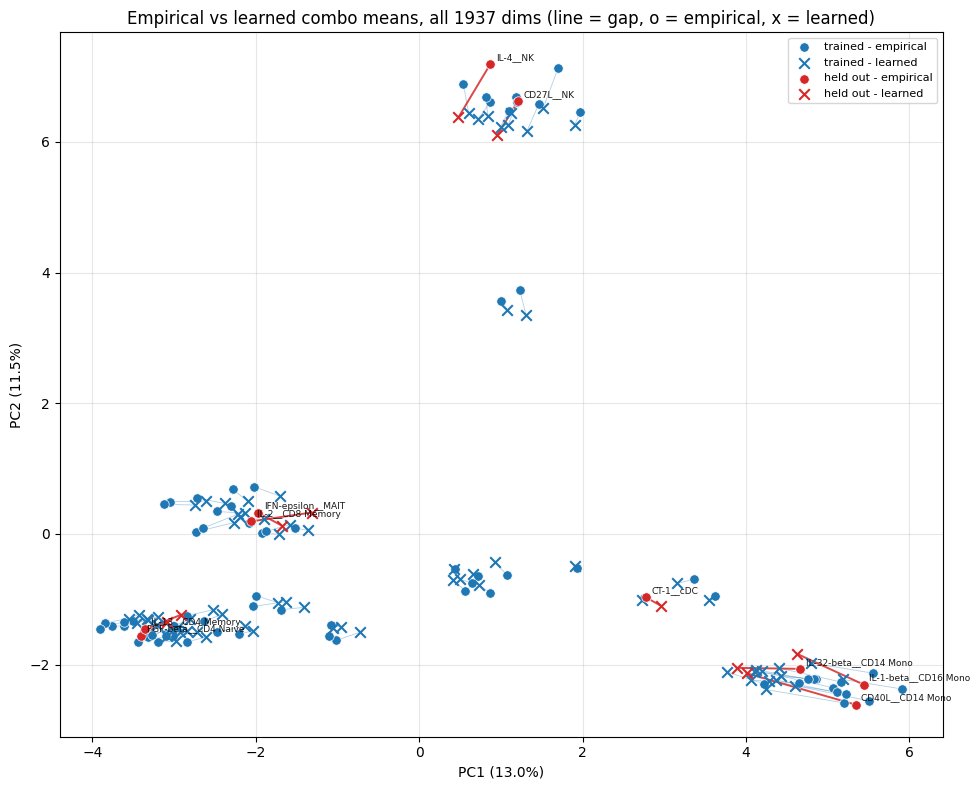

In [66]:
# Same comparison in 2D, over the FULL latent (all N_dim dims, not just the condition
# block). Learned and empirical means are projected through one shared PCA basis, and each
# pair is joined by a line - the length of that line is the gap, so held-out combos should
# show visibly longer lines than trained ones.
#
# What "all dimensions" includes: `model.means` is exactly zero in dims [means_dim:], so
# every learned point lies in a means_dim-dimensional subspace while the empirical points
# do not. The extra distance that creates is real on this plot but is finite-sample noise,
# not model error - see the note above. `DIMS` switches between the two views.
DIMS = None          # None = all N_dim dims (as asked); or analyzer.model.means_dim

conditions = list(analyzer.conditions)
labels_all = list(analyzer.combo_categories)
d = DIMS or analyzer.model.N_dim

Z_full = np.asarray(
    create_latent_adata(
        analyzer.adata, analyzer.model, analyzer.device,
        conditions, analyzer.condition_type,
    ).X
)[:, :d]
with torch.no_grad():
    learned_full = analyzer.model.means.cpu().numpy()[:, :d]

held_set = {"__".join(str(c[k]) for k in conditions)
            for c in (model_config.holdout_combos or HOLDOUT_LIST or [])}
combo_of_cell = analyzer.adata.obs[conditions].astype(str).agg("__".join, axis=1).to_numpy()

E, L, labs, held, ns = [], [], [], [], []
for i, label in enumerate(labels_all):
    mask = combo_of_cell == label
    if mask.sum() < MIN_CELLS:
        continue
    E.append(Z_full[mask].mean(0)); L.append(learned_full[i])
    labs.append(label); held.append(label in held_set); ns.append(int(mask.sum()))
E, L, held = np.stack(E), np.stack(L), np.array(held)
print(f"{len(labs)} combos over {d} dims ({int(held.sum())} held out)")

pca = PCA(n_components=2)
proj = pca.fit_transform(np.vstack([E, L]))
E2, L2 = proj[: len(E)], proj[len(E) :]

fig, ax = plt.subplots(figsize=(10, 8))
for is_held, color, name in [(False, "tab:blue", "trained"), (True, "tab:red", "held out")]:
    sel = held == is_held
    for i in np.flatnonzero(sel):
        ax.plot(*zip(E2[i], L2[i]), color=color, lw=1.4 if is_held else 0.6,
                alpha=0.85 if is_held else 0.35, zorder=2 if is_held else 1)
    ax.scatter(*E2[sel].T, color=color, marker="o", s=46, zorder=3,
               edgecolor="white", linewidth=0.5, label=f"{name} - empirical")
    ax.scatter(*L2[sel].T, color=color, marker="x", s=58, zorder=3,
               label=f"{name} - learned")
for i in np.flatnonzero(held):
    ax.annotate(labs[i], E2[i], fontsize=6.5, alpha=0.9,
                xytext=(4, 3), textcoords="offset points")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title(f"Empirical vs learned combo means, all {d} dims "
             f"(line = gap, o = empirical, x = learned)")
ax.legend(fontsize=8, loc="best")
ax.grid(alpha=0.3)

gap_full = np.linalg.norm(E - L, axis=1)
print(f"  full-space gap: trained median {np.median(gap_full[~held]):.3f}, "
      f"held-out median {np.median(gap_full[held]):.3f} "
      f"({np.median(gap_full[held]) / np.median(gap_full[~held]):.2f}x)")
print(f"  PC1+PC2 capture {pca.explained_variance_ratio_[:2].sum():.1%} of the variance - "
      "a long line in 2D is a lower bound on the true gap")

plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, "composed_mean_gap_pca.png"), dpi=300,
            bbox_inches="tight")
plt.show()

## 6. scib Benchmarker

`scib_metrics.Benchmarker` scores an embedding on two axes - **bio-conservation** of a
`label_key` (NMI/ARI/silhouette/isolated labels/kNN purity) and **batch-correction** of a
`batch_key` (iLISI, kBET, graph connectivity, PCR).

**Read the batch column with care here.** The old `experiments.ipynb` setup used
`batch_key="patient"`, where mixing batches is unambiguously good. This dataset is a
single donor (`DONOR = ["Donor1"]`) and `adata.obs` carries only `cell_type`, `cytokine`
and `n_cells` - there is no nuisance batch. So `batch_key` has to be one of the two
biological factors, and a high batch score then means the embedding has *removed* a
signal we specifically want it to keep. **Only the bio-conservation half answers the
question in the title**; the batch half is a diagnostic of how strongly the other factor
is entangled, not a target to maximise.

Two complementary runs:

| run | label (want high) | batch (diagnostic) |
|---|---|---|
| A | `cell_type` | `cytokine` |
| B | `cytokine` | `cell_type` |

The embeddings compared are chosen to isolate where the structure lives:

- `X_pca` - baseline on the same 1937 HVGs.
- `X_flow` - the full latent. The flow is a bijection, so this is the raw data in new
  coordinates; it mostly calibrates how much the change of metric alone does.
- `X_flow_cond` - the **first `means_dim` dims**, the condition block the mixture prior
  actually parameterises.
- `X_flow_shared` - the remaining dims, which share one N(0,1) prior across every combo.

`X_flow_cond` vs `X_flow_shared` is the real experiment: if the prior is doing its job,
cell type and cytokine structure should concentrate in the condition block, and the
shared block should look closer to unstructured.

In [28]:
# jax is imported by scib_metrics; these must be set BEFORE that import or the
# x64/jit defaults differ from what experiments.ipynb used.
import os
os.environ["JAX_ENABLE_X64"] = "False"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
import jax
jax.config.update("jax_enable_x64", False)

import gc
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

bench_adata = analyzer.adata.copy()

# the flow latent, and the two blocks the partitioned prior splits it into
latent_adata = create_latent_adata(
    bench_adata, analyzer.model, analyzer.device, analyzer.conditions, analyzer.condition_type
)
Z = np.asarray(latent_adata.X, dtype="float32")
MD_ = analyzer.model.means_dim
bench_adata.obsm["X_flow"] = Z
bench_adata.obsm["X_flow_cond"] = Z[:, :MD_]
if MD_ < Z.shape[1]:
    bench_adata.obsm["X_flow_shared"] = Z[:, MD_:]

sc.pp.pca(bench_adata, n_comps=50)

# scib is strict about dtypes; the old notebook coerced these too
for k in list(bench_adata.obsm):
    bench_adata.obsm[k] = np.asarray(bench_adata.obsm[k], dtype="float32")
bench_adata.X = bench_adata.X.astype("float32")

EMB = [k for k in ["X_pca", "X_flow", "X_flow_cond", "X_flow_shared"] if k in bench_adata.obsm]
print(f"means_dim={MD_} of {Z.shape[1]}")
print({k: bench_adata.obsm[k].shape for k in EMB})

means_dim=464 of 1937
{'X_pca': (12383, 50), 'X_flow': (12383, 1937), 'X_flow_cond': (12383, 464), 'X_flow_shared': (12383, 1473)}


In [29]:
# Run A - does the embedding preserve CELL TYPE?
# n_jobs: the interactive allocation gives 8 CPUs, and an srun step only 2 by default.
bm_cell_type = Benchmarker(
    bench_adata,
    batch_key="cytokine",          # diagnostic only - see the note above
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=None,
    embedding_obsm_keys=EMB,
    n_jobs=4,
)
bm_cell_type.benchmark()
gc.collect()
bm_cell_type.plot_results_table(min_max_scale=False)

Embeddings:   0%|                                                                                 | 0/4 [00:00<?, ?it/s]E0827 11:05:18.285205 1951585 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0827 11:05:18.285305 1951586 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0827 11:05:18.285337 1951587 numa_hwloc.cc:121] Call to hwloc_set_cpubind() failed: Invalid argument [22]
E0827 11:07:19.068039 1951600 slow_operation_alarm.cc:73] 
********************************
[Compiling module input_reduce_fusion for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************
E0827 11:07:57.279174 1951591 slow_operation_alarm.cc:140] The operation took 2m38.211231202s

********************************
[Compiling module input_reduce_fusion for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/fo

KeyboardInterrupt: 

Embeddings: 100%|█████████████████████████████████████████████████████████████████████████| 4/4 [00:27<00:00,  6.95s/it]


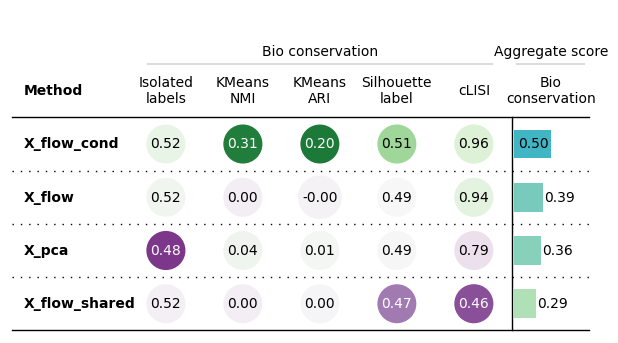

In [ ]:
# Run B - does the embedding preserve CYTOKINE?
bm_cytokine = Benchmarker(
    bench_adata,
    batch_key="cell_type",         # diagnostic only
    label_key="cytokine",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=None,
    embedding_obsm_keys=EMB,
    n_jobs=4,
)
bm_cytokine.benchmark()
gc.collect()
bm_cytokine.plot_results_table(min_max_scale=False)

In [ ]:
import pandas as pd

# Bio-conservation side by side. This is the number that answers the section title;
# the condition block should beat the shared block if the prior is carrying the biology.
bio_ct = bm_cell_type.get_results(min_max_scale=False)["Bio conservation"]
bio_cy = bm_cytokine.get_results(min_max_scale=False)["Bio conservation"]
cmp = pd.DataFrame({"bio(cell_type)": bio_ct, "bio(cytokine)": bio_cy}).loc[EMB]
display(cmp.round(3))

for name, bm in [("cell_type", bm_cell_type), ("cytokine", bm_cytokine)]:
    bm.get_results(min_max_scale=False).to_csv(
        os.path.join(analyzer.csv_dir, f"scib_{name}.csv")
    )
print(f"written to {analyzer.csv_dir}")

,bio(cell_type),bio(cytokine)
Embedding,,
X_pca,0.664839,0.36278
X_flow,0.579774,0.389608
X_flow_cond,0.6552,0.500207
X_flow_shared,0.516656,0.291108


written to /home/jhoefer/sandbox/results/parse/top_1937_metacells_holdout_combos_factorized/csv/MTC_0.6_sigma_0.5


## 7. Compositional counterfactuals: one shift or two?

Move a cell from `(cy_src, ct_src)` to `(cy_dst, ct_dst)` two ways:

- **one-shot** - `decode(encode(x) + d_ct + d_cy)`
- **two-stage** - change cell type, decode, *re-encode*, then change cytokine

The flow is a bijection, so `f(f^-1(z)) = z` and the two are **algebraically identical**:

    f^-1( f( f^-1(f(x) + d_ct) ) + d_cy )  =  f^-1( f(x) + d_ct + d_cy )

So this is not a test of composition - it is a test of how much **numerical** error an
extra encode/decode cycle costs in float32. A large gap means the flow's analytic inverse
is drifting, which would quietly corrupt any multi-step latent arithmetic. The flow's own
round-trip `f(f^-1(z)) - z` is reported alongside as the floor to read the gap against.

Both orders (`ct->cy` and `cy->ct`) are run: they are the same point algebraically, so
any disagreement between them is numerical too.

The shifts telescope by construction - `d_ct` is taken at the source cytokine and `d_cy`
at the destination cell type - so `d_ct + d_cy = mu(dst) - mu(src)` exactly, and this
stays true under `treatment_gain`, where the treatment shift is cell-type dependent and
reading `b_cy` off the factor embedding directly would not.

In [29]:
SRC = {"cytokine": control_label, "cell_type": "CD4 Memory"}
DST = {"cytokine": "IL-2",       "cell_type": "CD14 Mono"}
N_CELLS = 256

conds = list(analyzer.conditions)
combo_cats = list(analyzer.combo_categories)

def combo_idx(values):
    label = "__".join(str(values[c]) for c in conds)
    if label not in combo_cats:
        raise KeyError(f"{label!r} is not in combo_categories")
    return combo_cats.index(label)

means = analyzer.model.means.detach()

# route via the intermediate (cell type changed first, cytokine still at source), so the
# two legs telescope to the full displacement whatever the prior's interaction form
MID_CT = {**SRC, "cell_type": DST["cell_type"]}   # ct leg first
MID_CY = {**SRC, "cytokine": DST["cytokine"]}     # cy leg first
d_ct = means[combo_idx(MID_CT)] - means[combo_idx(SRC)]
d_cy = means[combo_idx(DST)]    - means[combo_idx(MID_CT)]
d_cy_first = means[combo_idx(MID_CY)] - means[combo_idx(SRC)]
d_ct_second = means[combo_idx(DST)]   - means[combo_idx(MID_CY)]
d_total = means[combo_idx(DST)] - means[combo_idx(SRC)]
assert torch.allclose(d_ct + d_cy, d_total, atol=1e-5)
assert torch.allclose(d_cy_first + d_ct_second, d_total, atol=1e-5)

obs = analyzer.adata.obs
mask = np.ones(analyzer.adata.n_obs, dtype=bool)
for k, v in SRC.items():
    mask &= (obs[k].astype(str) == v).to_numpy()
print(f"{mask.sum()} source cells at {SRC}")
idx = np.flatnonzero(mask)
if len(idx) > N_CELLS:
    idx = np.random.default_rng(0).choice(idx, N_CELLS, replace=False)

X0 = analyzer.adata.X[idx]
X0 = X0.toarray() if hasattr(X0, "toarray") else np.asarray(X0)
x0 = torch.as_tensor(X0, device=analyzer.device, dtype=analyzer.dtype)
with torch.no_grad():
    z0, _ = analyzer.model(x0, rev=False)
print(f"encoded {tuple(x0.shape)} -> {tuple(z0.shape)}")

1327 source cells at {'cytokine': 'PBS', 'cell_type': 'CD4 Memory'}
encoded (256, 1937) -> (256, 1937)


In [30]:
@torch.no_grad()
def decode(z):
    return analyzer.model(z, rev=True)[0]

@torch.no_grad()
def encode(x):
    return analyzer.model(x, rev=False)[0]

def staged(z, first, second):
    """decode after `first`, re-encode, then apply `second`."""
    return decode(encode(decode(z + first)) + second)

x_one = decode(z0 + d_total)
variants = {
    "two-stage ct->cy": staged(z0, d_ct, d_cy),
    "two-stage cy->ct": staged(z0, d_cy_first, d_ct_second),
}

# the flow's own round-trip error, as the floor any staged result must be read against
rt = (encode(decode(z0)) - z0).abs()
scale = x_one.abs().mean().item()
rows = [{"variant": "flow round-trip f(f^-1(z)) - z  [latent]",
         "max_abs": rt.max().item(), "mean_abs": rt.mean().item(),
         "rel_mean": float("nan"), "cosine": float("nan")}]
for name, xv in variants.items():
    d = (xv - x_one).abs()
    cos = torch.nn.functional.cosine_similarity(
        xv.flatten(), x_one.flatten(), dim=0).item()
    rows.append({"variant": name, "max_abs": d.max().item(), "mean_abs": d.mean().item(),
                 "rel_mean": d.mean().item() / scale, "cosine": cos})
res = pd.DataFrame(rows)
print(f"mean |x_one-shot| = {scale:.4f}   (rel_mean is relative to this)\n")
print(res.to_string(index=False, float_format=lambda v: f"{v:.3e}"))

mean |x_one-shot| = 0.7670   (rel_mean is relative to this)

                                 variant   max_abs  mean_abs  rel_mean    cosine
flow round-trip f(f^-1(z)) - z  [latent] 3.213e-03 2.145e-04       NaN       NaN
                        two-stage ct->cy 2.117e-03 1.405e-04 1.832e-04 1.000e+00
                        two-stage cy->ct 3.423e-03 1.635e-04 2.131e-04 1.000e+00


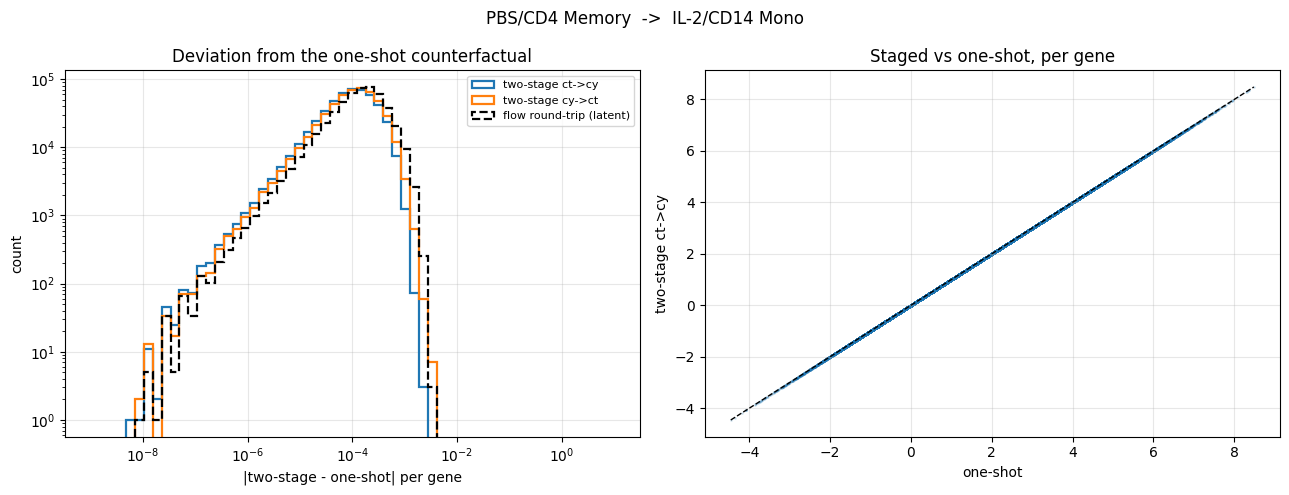

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

a = axes[0]
for name, xv in variants.items():
    err = (xv - x_one).abs().flatten().cpu().numpy()
    a.hist(err[err > 0], bins=np.logspace(-9, 1, 60), histtype="step", lw=1.6, label=name)
a.hist(rt.flatten().cpu().numpy(), bins=np.logspace(-9, 1, 60), histtype="step",
       lw=1.6, ls="--", color="black", label="flow round-trip (latent)")
a.set_xscale("log"); a.set_yscale("log")
a.set_xlabel("|two-stage - one-shot| per gene"); a.set_ylabel("count")
a.set_title("Deviation from the one-shot counterfactual")
a.legend(fontsize=8); a.grid(alpha=0.3)

b = axes[1]
key = "two-stage ct->cy"
b.scatter(x_one.flatten().cpu().numpy(), variants[key].flatten().cpu().numpy(),
          s=1, alpha=0.15)
lim = [float(x_one.min()), float(x_one.max())]
b.plot(lim, lim, color="black", lw=1, ls="--")
b.set_xlabel("one-shot"); b.set_ylabel(key)
b.set_title("Staged vs one-shot, per gene")
b.grid(alpha=0.3)

plt.suptitle(f"{SRC['cytokine']}/{SRC['cell_type']}  ->  {DST['cytokine']}/{DST['cell_type']}")
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, "compositional_counterfactuals.png"),
            dpi=300, bbox_inches="tight")
plt.show()